# Chapter 3: Exploratory Data Analysis
## Understanding Health Insurance Cost Predictions Using Deep Neural Networks, Monte Carlo Simulation and Shapley Values

**Author:** Thabang Bongani Junior Baloyi (2015015486)  
**Degree:** MSc Mathematical Statistics and Actuarial Sciences  
**Institution:** University of the Free State  
**Supervisor:** Mr. J. Blomerous (FASSA)

---

This notebook performs the exploratory data analysis (EDA) for Chapter 3 of the dissertation. It covers:
1. Loading and inspecting the raw dataset
2. Data audit (missing values, data types, range checks)
3. Missing-value visualisation
4. Numeric variable distributions and summary statistics
5. Categorical variable frequencies
6. Response variable analysis (charges) with QQ plot
7. Conditional analysis: charges by every categorical predictor
8. Interaction effects (smoker x coverage, smoker x medical history)
9. Correlation analysis (numeric and full encoded matrix)
10. Post-encoding diagnostics on the model-ready split files
11. Split-consistency check (overlaid density plots)
12. Principal component analysis of the model-ready input space (mathematical formulation, PCA scatter plots, loading vectors)
13. Correlation heatmaps: standardised inputs and actual target

## 1. Setup and Library Imports

In [1]:
# Import required libraries for data manipulation and visualisation
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# Set plotting style: no grid, clean white background
sns.set_style('white')
plt.rcParams.update({
    'figure.figsize': (10, 6),
    'font.size': 12,
    'axes.titlesize': 14,
    'axes.labelsize': 12,
    'axes.grid': False,          # disable grid globally
    'figure.facecolor': 'white',
    'axes.facecolor': 'white',
    'savefig.facecolor': 'white',
    'savefig.dpi': 300,
    'savefig.bbox': 'tight',
})

# Output directory for all saved figures
FIG_DIR = '/Users/baloyithabangbonganijunior/Downloads/chapter3_figures/'

# Display options for pandas
pd.set_option('display.max_columns', 25)
pd.set_option('display.float_format', '{:,.4f}'.format)

print('Libraries loaded successfully.')
print(f'Figures will be saved to: {FIG_DIR}')

Libraries loaded successfully.
Figures will be saved to: /Users/baloyithabangbonganijunior/Downloads/chapter3_figures/


## 2. Load the Raw Dataset

In [2]:
# Load the raw Insurance Data for Machine Learning dataset from Kaggle
# Source: https://www.kaggle.com/ (CC0 public-domain licence)
# n = 1,000,000 observations, 12 variables (11 predictors + 1 response)

RAW_PATH = '/Users/baloyithabangbonganijunior/Downloads/insurance_dataset.csv'
df = pd.read_csv(RAW_PATH)

print(f'Dataset shape: {df.shape[0]:,} rows x {df.shape[1]} columns')
print(f'Memory usage: {df.memory_usage(deep=True).sum() / 1e6:.1f} MB')

Dataset shape: 1,000,000 rows x 12 columns


Memory usage: 476.9 MB


In [3]:
# Display the first five rows to verify successful loading
df.head()

,age,gender,bmi,children,smoker,region,medical_history,family_medical_history,exercise_frequency,occupation,coverage_level,charges
0,46,male,21.4500,5,yes,southeast,Diabetes,NaN,Never,Blue collar,Premium,"20,460.3077"
1,25,female,25.3800,2,yes,northwest,Diabetes,High blood pressure,Occasionally,White collar,Premium,"20,390.8992"
2,38,male,44.8800,2,yes,southwest,NaN,High blood pressure,Occasionally,Blue collar,Premium,"20,204.4763"
3,25,male,19.8900,0,no,northwest,NaN,Diabetes,Rarely,White collar,Standard,"11,789.0298"
4,49,male,38.2100,3,yes,northwest,Diabetes,High blood pressure,Rarely,White collar,Standard,"19,268.3098"


In [4]:
# Display column names and data types
# Numeric: age (int), bmi (float), children (int), charges (float)
# Categorical: gender, smoker, region, medical_history, family_medical_history,
#              exercise_frequency, occupation, coverage_level

df.dtypes

age                         int64
gender                        str
bmi                       float64
children                    int64
smoker                        str
region                        str
medical_history               str
family_medical_history        str
exercise_frequency            str
occupation                    str
coverage_level                str
charges                   float64
dtype: object

## 3. Data Audit

Systematic checks for missing values, duplicates, data types and value ranges.

In [5]:
# 3.1 Missing values per column
# Two variables have missing entries: medical_history and family_medical_history
# These represent ~25% of observations each, consistent with a 'None' category

missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
print('=== Missing Values Summary ===')
print(missing_df)
print(f'\nTotal complete columns: {(missing == 0).sum()} / {len(missing)}')

=== Missing Values Summary ===
                        Missing Count  Missing %
age                                 0     0.0000
gender                              0     0.0000
bmi                                 0     0.0000
children                            0     0.0000
smoker                              0     0.0000
region                              0     0.0000
medical_history                250762    25.0800
family_medical_history         250404    25.0400
exercise_frequency                  0     0.0000
occupation                          0     0.0000
coverage_level                      0     0.0000
charges                             0     0.0000

Total complete columns: 10 / 12


In [6]:
# 3.2 Check for duplicate rows
# No exact duplicates are expected in a generated benchmark dataset

n_duplicates = df.duplicated().sum()
print(f'Number of exact duplicate rows: {n_duplicates:,}')

Number of exact duplicate rows: 0


In [7]:
# 3.3 Range checks for numeric variables
# Verify that all values fall within plausible bounds

numeric_cols = ['age', 'bmi', 'children', 'charges']
range_check = df[numeric_cols].agg(['min', 'max']).T
range_check.columns = ['Minimum', 'Maximum']
print('=== Range Checks for Numeric Variables ===')
print(range_check)

=== Range Checks for Numeric Variables ===
            Minimum     Maximum
age         18.0000     65.0000
bmi         18.0000     50.0000
children     0.0000      5.0000
charges  3,445.0116 32,561.5604


In [8]:
# 3.4 Unique values for categorical variables
# This confirms the levels present in each categorical column

cat_cols = ['gender', 'smoker', 'region', 'medical_history',
            'family_medical_history', 'exercise_frequency',
            'occupation', 'coverage_level']

for col in cat_cols:
    unique_vals = df[col].dropna().unique()
    n_missing = df[col].isna().sum()
    print(f'{col}: {len(unique_vals)} levels {list(unique_vals)}'
          f'{f" + {n_missing:,} NaN" if n_missing > 0 else ""}')

gender: 2 levels ['male', 'female']
smoker: 2 levels ['yes', 'no']
region: 4 levels ['southeast', 'northwest', 'southwest', 'northeast']
medical_history: 3 levels ['Diabetes', 'High blood pressure', 'Heart disease'] + 250,762 NaN


family_medical_history: 3 levels ['High blood pressure', 'Diabetes', 'Heart disease'] + 250,404 NaN


exercise_frequency: 4 levels ['Never', 'Occasionally', 'Rarely', 'Frequently']
occupation: 4 levels ['Blue collar', 'White collar', 'Student', 'Unemployed']
coverage_level: 3 levels ['Premium', 'Standard', 'Basic']


### 3.5 Missing-Value Visualisation

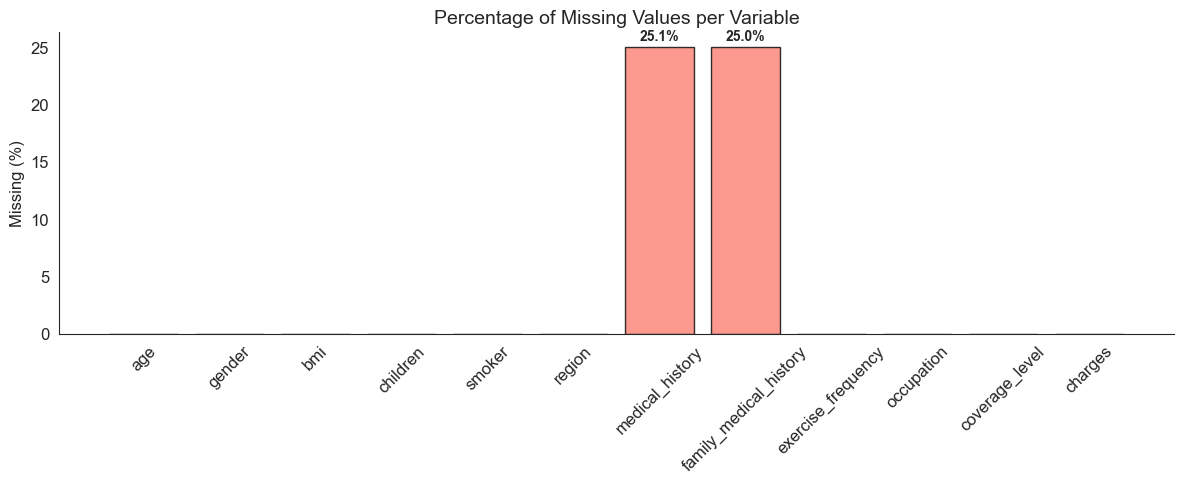

Figure saved: fig_missing_values.png


In [9]:
# 3.5 Bar chart of missing-value percentages per column
# Only medical_history and family_medical_history have missing values (~25% each)
# All other columns are fully observed

fig, ax = plt.subplots(figsize=(12, 5))
colours = ['salmon' if p > 0 else 'steelblue' for p in missing_pct]
ax.bar(missing_pct.index, missing_pct.values, color=colours, edgecolor='black', alpha=0.8)
ax.set_ylabel('Missing (%)')
ax.set_title('Percentage of Missing Values per Variable')
ax.tick_params(axis='x', rotation=45)
# Add percentage labels on bars with missing values
for i, (col, pct) in enumerate(missing_pct.items()):
    if pct > 0:
        ax.text(i, pct + 0.5, f'{pct:.1f}%', ha='center', fontsize=10, fontweight='bold')
sns.despine()
plt.tight_layout()
plt.savefig(FIG_DIR + 'fig_missing_values.png', dpi=300, bbox_inches='tight')
plt.show()
print('Figure saved: fig_missing_values.png')

## 4. Numeric Variable Distributions

Descriptive statistics, skewness, kurtosis and histogram plots for the numeric variables.

In [10]:
# 4.1 Full descriptive statistics for numeric variables
# Includes count, mean, std, min, quartiles, max

desc = df[numeric_cols].describe().T
desc['skewness'] = df[numeric_cols].skew()
desc['kurtosis'] = df[numeric_cols].kurtosis()
print('=== Descriptive Statistics for Numeric Variables ===')
desc

=== Descriptive Statistics for Numeric Variables ===


,count,mean,std,min,25%,50%,75%,max,skewness,kurtosis
age,"1,000,000.0000",41.4953,13.8552,18.0000,29.0000,41.0000,53.0000,65.0000,0.0007,-1.2006
bmi,"1,000,000.0000",34.0018,9.2317,18.0000,26.0200,34.0000,41.9900,50.0000,-0.0004,-1.1982
children,"1,000,000.0000",2.4999,1.7077,0.0000,1.0000,2.0000,4.0000,5.0000,0.0003,-1.2680
charges,"1,000,000.0000","16,735.1175","4,415.8082","3,445.0116","13,600.3724","16,622.1280","19,781.4654","32,561.5604",0.1303,-0.3485


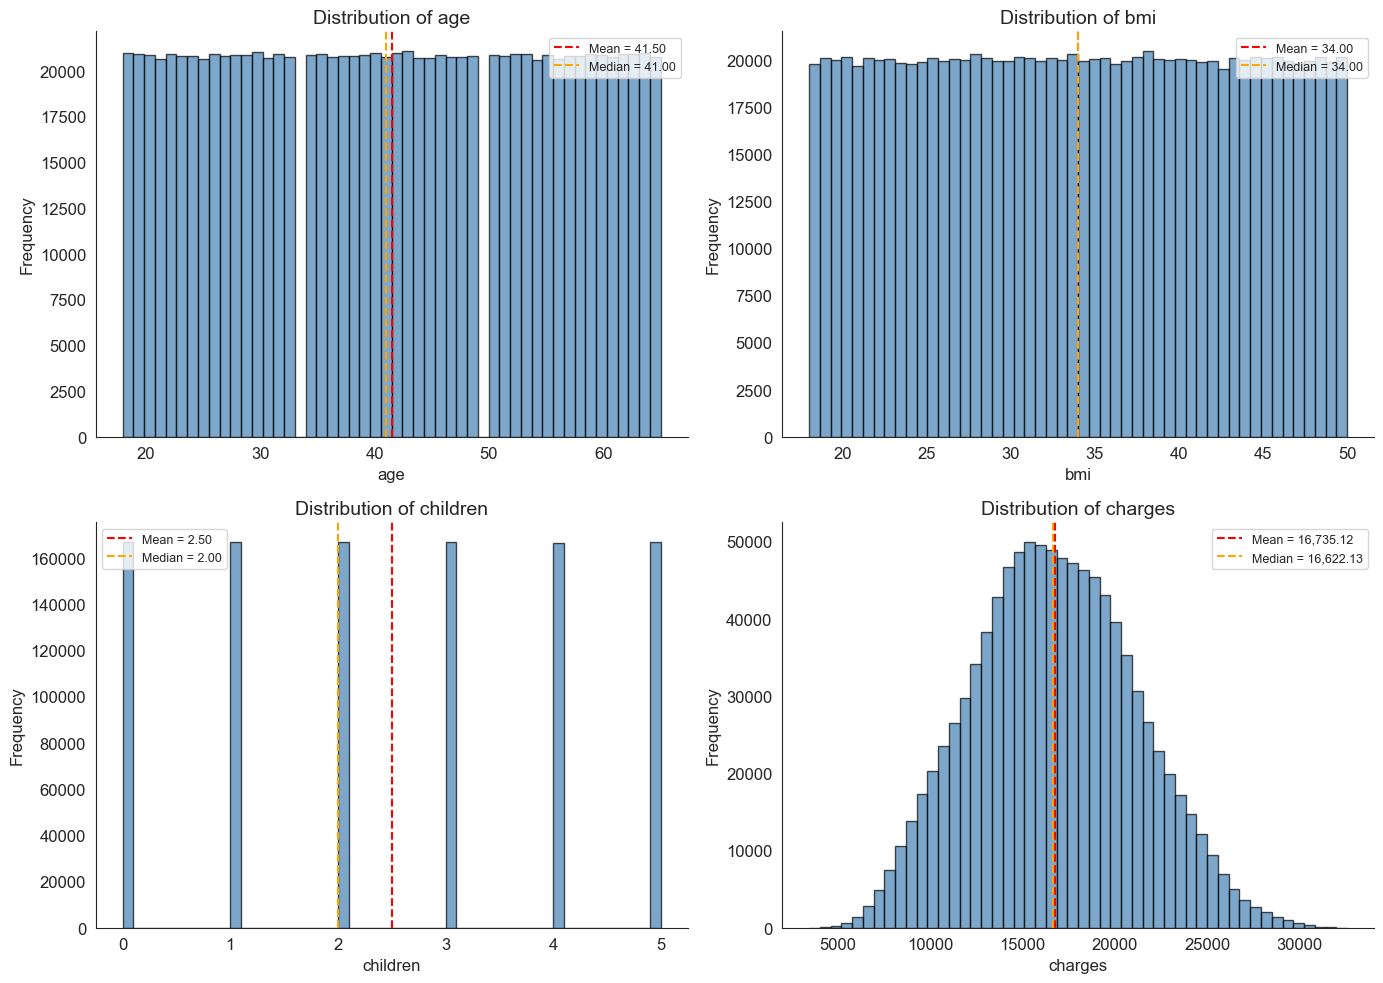

Figure saved: fig_numeric_distributions.png


In [11]:
# 4.2 Histograms for all numeric variables
# Each subplot shows the distribution of one numeric variable
# The near-uniform shape of age, bmi and children is a property of the benchmark data

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for ax, col in zip(axes.flatten(), numeric_cols):
    ax.hist(df[col], bins=50, edgecolor='black', alpha=0.7, color='steelblue')
    ax.axvline(df[col].mean(), color='red', linestyle='--', linewidth=1.5,
               label=f'Mean = {df[col].mean():,.2f}')
    ax.axvline(df[col].median(), color='orange', linestyle='--', linewidth=1.5,
               label=f'Median = {df[col].median():,.2f}')
    ax.set_title(f'Distribution of {col}')
    ax.set_xlabel(col)
    ax.set_ylabel('Frequency')
    ax.legend(fontsize=9)
    sns.despine(ax=ax)

plt.tight_layout()
plt.savefig(FIG_DIR + 'fig_numeric_distributions.png', dpi=300, bbox_inches='tight')
plt.show()
print('Figure saved: fig_numeric_distributions.png')

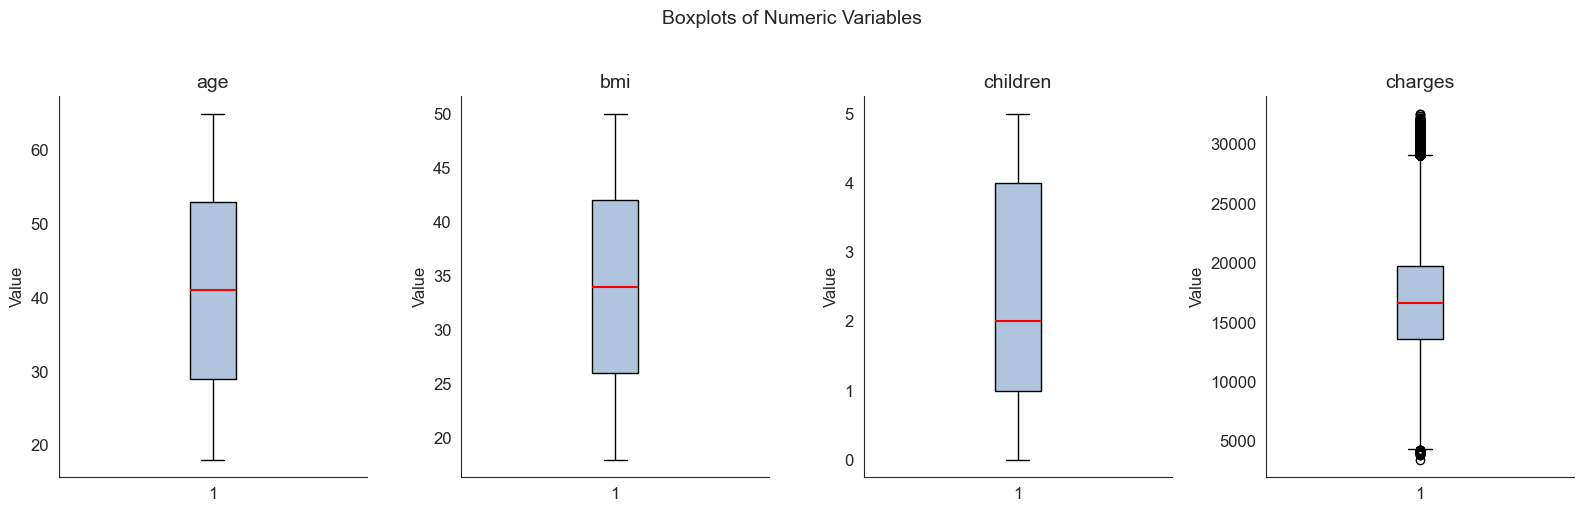

Figure saved: fig_numeric_boxplots.png


In [12]:
# 4.3 Boxplots for numeric variables
# Useful for identifying outliers and comparing spread

fig, axes = plt.subplots(1, 4, figsize=(16, 5))

for ax, col in zip(axes, numeric_cols):
    bp = ax.boxplot(df[col].dropna(), vert=True, patch_artist=True,
                    boxprops=dict(facecolor='lightsteelblue', edgecolor='black'),
                    medianprops=dict(color='red', linewidth=1.5),
                    whiskerprops=dict(color='black'),
                    capprops=dict(color='black'))
    ax.set_title(col)
    ax.set_ylabel('Value')
    sns.despine(ax=ax)

plt.suptitle('Boxplots of Numeric Variables', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig(FIG_DIR + 'fig_numeric_boxplots.png', dpi=300, bbox_inches='tight')
plt.show()
print('Figure saved: fig_numeric_boxplots.png')

## 5. Categorical Variable Frequencies

Bar charts and frequency tables for all categorical predictors.

In [13]:
# 5.1 Frequency tables for all categorical variables
# All categories are near-uniformly distributed (a designed property of the benchmark)

for col in cat_cols:
    vc = df[col].value_counts(dropna=False).sort_index()
    pct = (vc / len(df) * 100).round(2)
    freq_df = pd.DataFrame({'Count': vc, 'Percentage': pct})
    print(f'\n=== {col} ===')
    print(freq_df)


=== gender ===
         Count  Percentage
gender                    
female  499893     49.9900
male    500107     50.0100

=== smoker ===
         Count  Percentage
smoker                    
no      499871     49.9900
yes     500129     50.0100

=== region ===
            Count  Percentage
region                       
northeast  250343     25.0300
northwest  249931     24.9900
southeast  249631     24.9600
southwest  250095     25.0100

=== medical_history ===
                      Count  Percentage
medical_history                        
Diabetes             249335     24.9300
Heart disease        250121     25.0100
High blood pressure  249782     24.9800
NaN                  250762     25.0800

=== family_medical_history ===
                         Count  Percentage
family_medical_history                    
Diabetes                249737     24.9700
Heart disease           250035     25.0000
High blood pressure     249824     24.9800
NaN                     250404     25.0400



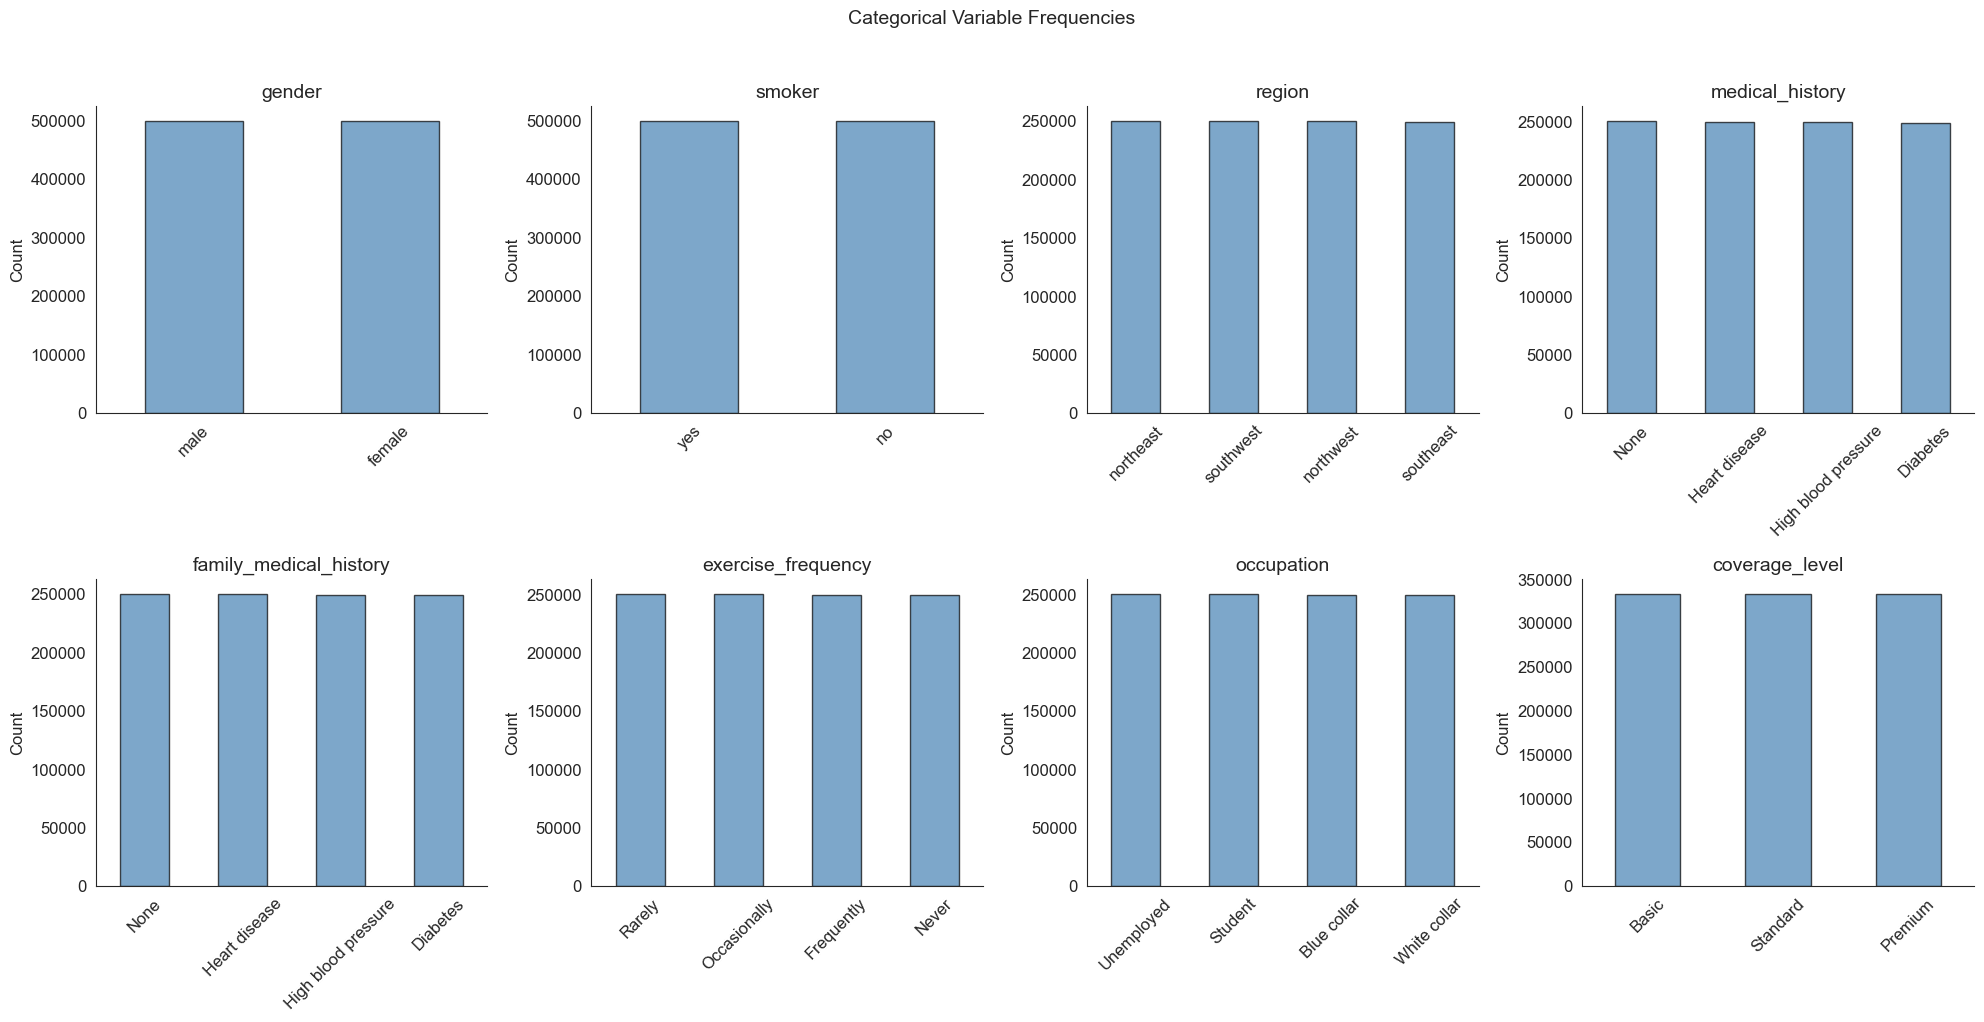

Figure saved: fig_categorical_frequencies.png


In [14]:
# 5.2 Bar charts for categorical variables
# Visualises the near-uniform distribution across all category levels

fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.flatten()

for ax, col in zip(axes, cat_cols):
    counts = df[col].value_counts(dropna=False)
    counts.index = [str(x) if pd.notna(x) else 'None' for x in counts.index]
    counts.plot(kind='bar', ax=ax, color='steelblue', edgecolor='black', alpha=0.7)
    ax.set_title(col)
    ax.set_ylabel('Count')
    ax.tick_params(axis='x', rotation=45)
    sns.despine(ax=ax)

plt.suptitle('Categorical Variable Frequencies', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig(FIG_DIR + 'fig_categorical_frequencies.png', dpi=300, bbox_inches='tight')
plt.show()
print('Figure saved: fig_categorical_frequencies.png')

## 6. Response Variable Analysis (charges)

Detailed analysis of the response variable including its distribution, percentiles and density.

In [15]:
# 6.1 Selected percentiles of charges
# These are needed for defining the high-cost threshold u in the Shapley analysis

percentiles = [1, 5, 10, 25, 50, 75, 90, 95, 99]
pct_values = np.percentile(df['charges'], percentiles)
pct_df = pd.DataFrame({'Percentile': [f'P{p}' for p in percentiles],
                        'Value (R)': pct_values})
print('=== Selected Percentiles of charges ===')
print(pct_df.to_string(index=False))

=== Selected Percentiles of charges ===
Percentile   Value (R)
        P1  7,520.1654
        P5  9,557.5820
       P10 10,947.1652
       P25 13,600.3724
       P50 16,622.1280
       P75 19,781.4654
       P90 22,591.3251
       P95 24,224.3752
       P99 27,016.4355


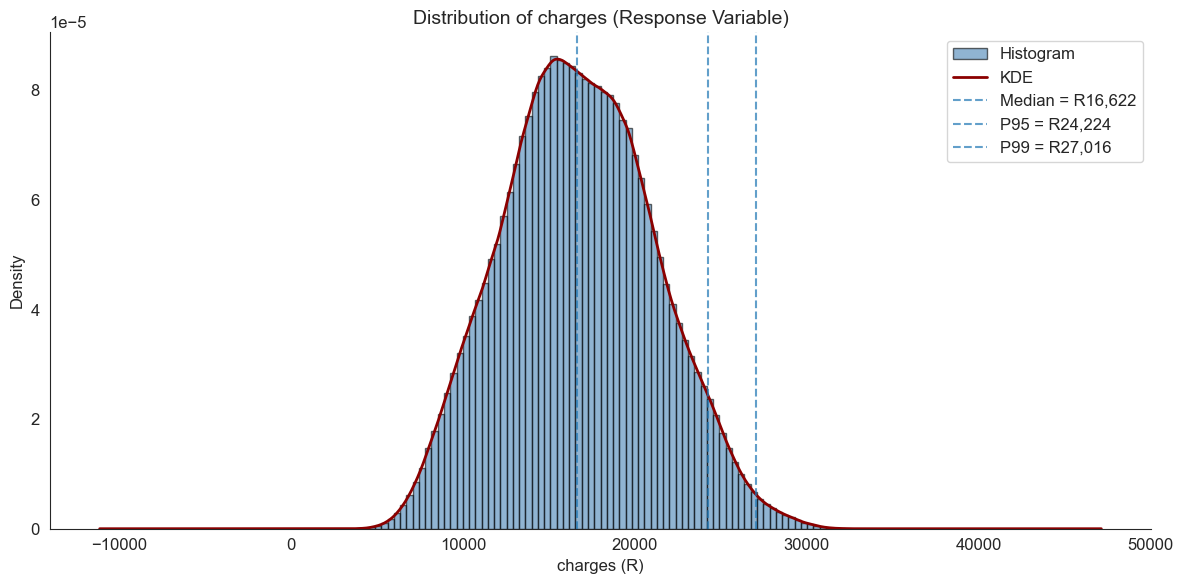

Skewness: 0.1303
Excess kurtosis: -0.3485
Figure saved: fig_charges_distribution.png


In [16]:
# 6.2 Histogram with kernel density estimate (KDE) for charges
# Mild positive skewness (0.13), near-symmetric distribution
# No log transformation is required

fig, ax = plt.subplots(figsize=(12, 6))
ax.hist(df['charges'], bins=80, density=True, edgecolor='black',
        alpha=0.6, color='steelblue', label='Histogram')
df['charges'].plot.kde(ax=ax, color='darkred', linewidth=2, label='KDE')

# Mark key percentiles
for p, label in [(50, 'Median'), (95, 'P95'), (99, 'P99')]:
    val = np.percentile(df['charges'], p)
    ax.axvline(val, linestyle='--', alpha=0.7,
               label=f'{label} = R{val:,.0f}')

ax.set_title('Distribution of charges (Response Variable)')
ax.set_xlabel('charges (R)')
ax.set_ylabel('Density')
ax.legend()
sns.despine()
plt.tight_layout()
plt.savefig(FIG_DIR + 'fig_charges_distribution.png', dpi=300, bbox_inches='tight')
plt.show()
print(f'Skewness: {df["charges"].skew():.4f}')
print(f'Excess kurtosis: {df["charges"].kurtosis():.4f}')
print('Figure saved: fig_charges_distribution.png')

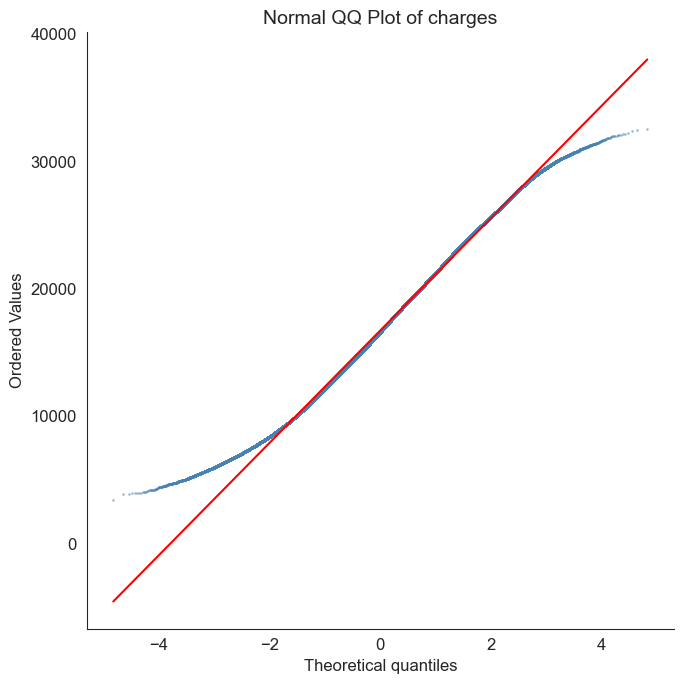

Figure saved: fig_charges_qqplot.png


In [17]:
# 6.3 QQ plot for charges against a normal distribution
# Assesses whether the response variable follows a Gaussian distribution
# Deviations at the tails indicate heavier/lighter tails than normal

fig, ax = plt.subplots(figsize=(7, 7))
stats.probplot(df['charges'], dist='norm', plot=ax)
ax.set_title('Normal QQ Plot of charges')
ax.get_lines()[0].set(marker='o', markersize=1, color='steelblue', alpha=0.4)
ax.get_lines()[1].set(color='red', linewidth=1.5)
sns.despine()
plt.tight_layout()
plt.savefig(FIG_DIR + 'fig_charges_qqplot.png', dpi=300, bbox_inches='tight')
plt.show()
print('Figure saved: fig_charges_qqplot.png')

## 7. Conditional Analysis: charges by Subgroup

Mean charges stratified by each categorical predictor, identifying which variables are associated with variation in the response.

In [18]:
# 7.1 Mean and SD of charges by each categorical predictor
# Smoker status shows the largest unconditional difference (~R5,000)
# Coverage level displays a clear tier structure
# Heart disease is associated with the highest mean charge among medical history levels

for col in cat_cols:
    grouped = df.groupby(col, dropna=False)['charges'].agg(['mean', 'std', 'count'])
    grouped.columns = ['Mean (R)', 'SD (R)', 'Count']
    grouped = grouped.sort_values('Mean (R)', ascending=False)
    grouped.index = [str(x) if pd.notna(x) else 'None' for x in grouped.index]
    print(f'\n=== charges by {col} ===')
    print(grouped.round(2))


=== charges by gender ===
          Mean (R)     SD (R)   Count
male   17,236.3200 4,385.1200  500107
female 16,233.7000 4,389.4000  499893

=== charges by smoker ===
       Mean (R)     SD (R)   Count
yes 19,234.7600 3,641.3900  500129
no  14,234.1900 3,638.1500  499871

=== charges by region ===
             Mean (R)     SD (R)   Count
northeast 17,235.9200 4,406.7100  250343
southeast 16,738.5500 4,406.7600  249631
northwest 16,528.6600 4,400.7500  249931
southwest 16,436.7200 4,405.6300  250095

=== charges by medical_history ===
                       Mean (R)     SD (R)   Count
Heart disease       19,739.1400 3,997.1000  250121
Diabetes            16,746.0800 3,994.1800  249335
High blood pressure 15,722.8700 4,002.9500  249782
None                14,736.1600 3,997.9200  250762

=== charges by family_medical_history ===
                       Mean (R)     SD (R)   Count
Heart disease       19,741.5500 3,996.6300  250035
Diabetes            16,736.3000 3,998.9800  249737
High blo


=== charges by coverage_level ===
            Mean (R)     SD (R)   Count
Premium  19,402.6700 3,904.1900  332977
Standard 16,413.0600 3,910.4200  333508
Basic    14,393.9200 3,907.4100  333515


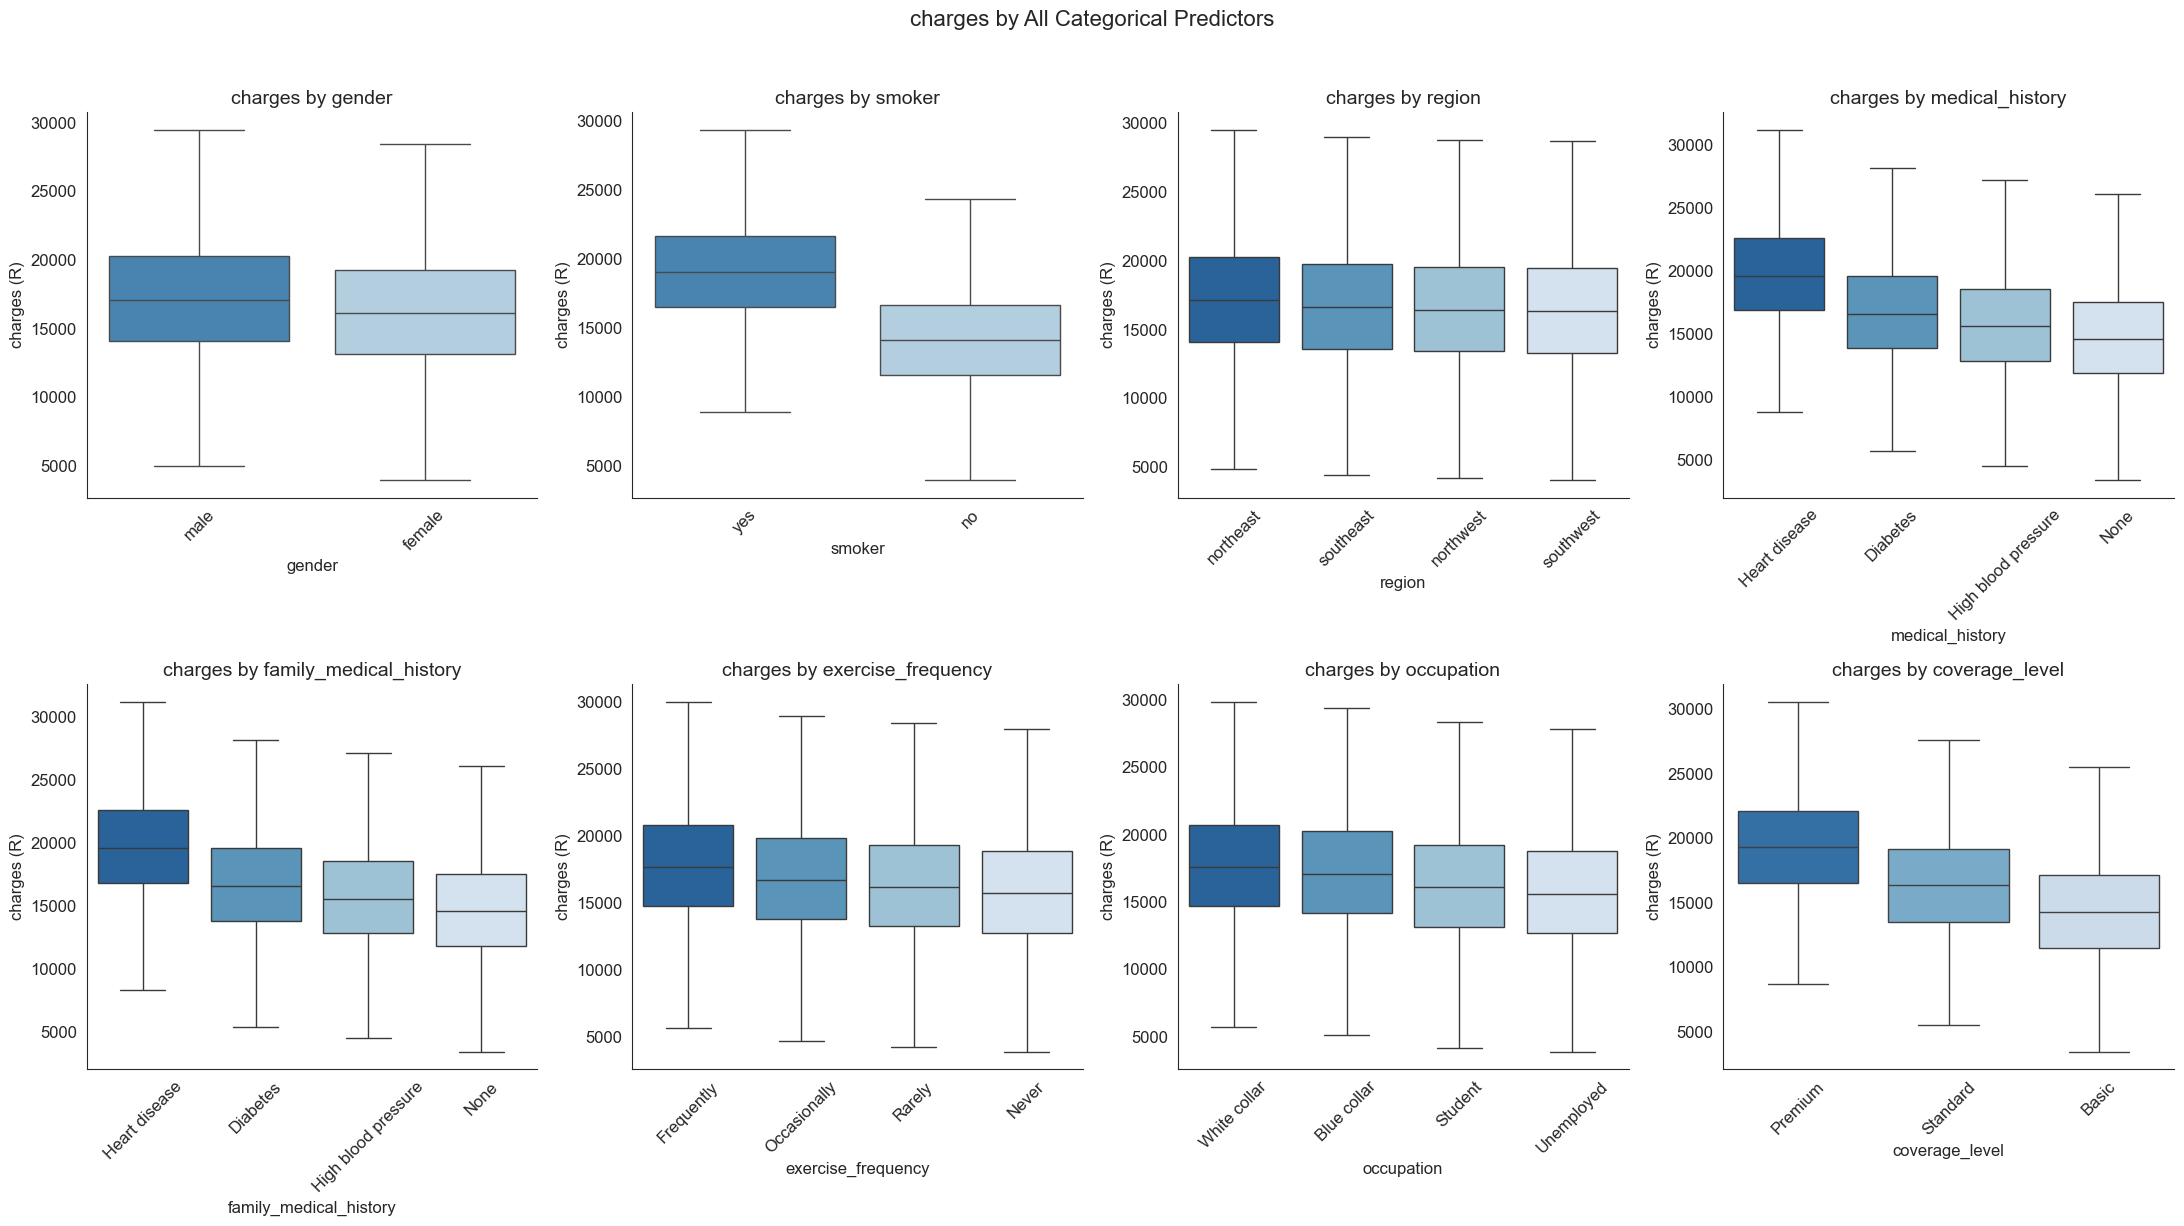

Figure saved: fig_charges_by_all_categoricals.png


In [19]:
# 7.2 Boxplots of charges by ALL categorical predictors (2 x 4 grid)
# Shows how the response variable varies across every categorical subgroup

fig, axes = plt.subplots(2, 4, figsize=(22, 12))
axes = axes.flatten()

for ax, col in zip(axes, cat_cols):
    plot_df = df[[col, 'charges']].copy()
    plot_df[col] = plot_df[col].fillna('None')
    order = plot_df.groupby(col)['charges'].mean().sort_values(ascending=False).index
    sns.boxplot(data=plot_df, x=col, y='charges', order=order, ax=ax,
                palette='Blues_r', showfliers=False)
    ax.set_title(f'charges by {col}')
    ax.set_xlabel(col)
    ax.set_ylabel('charges (R)')
    ax.tick_params(axis='x', rotation=45)
    sns.despine(ax=ax)

plt.suptitle('charges by All Categorical Predictors', fontsize=16, y=1.02)
plt.tight_layout()
plt.savefig(FIG_DIR + 'fig_charges_by_all_categoricals.png', dpi=300, bbox_inches='tight')
plt.show()
print('Figure saved: fig_charges_by_all_categoricals.png')

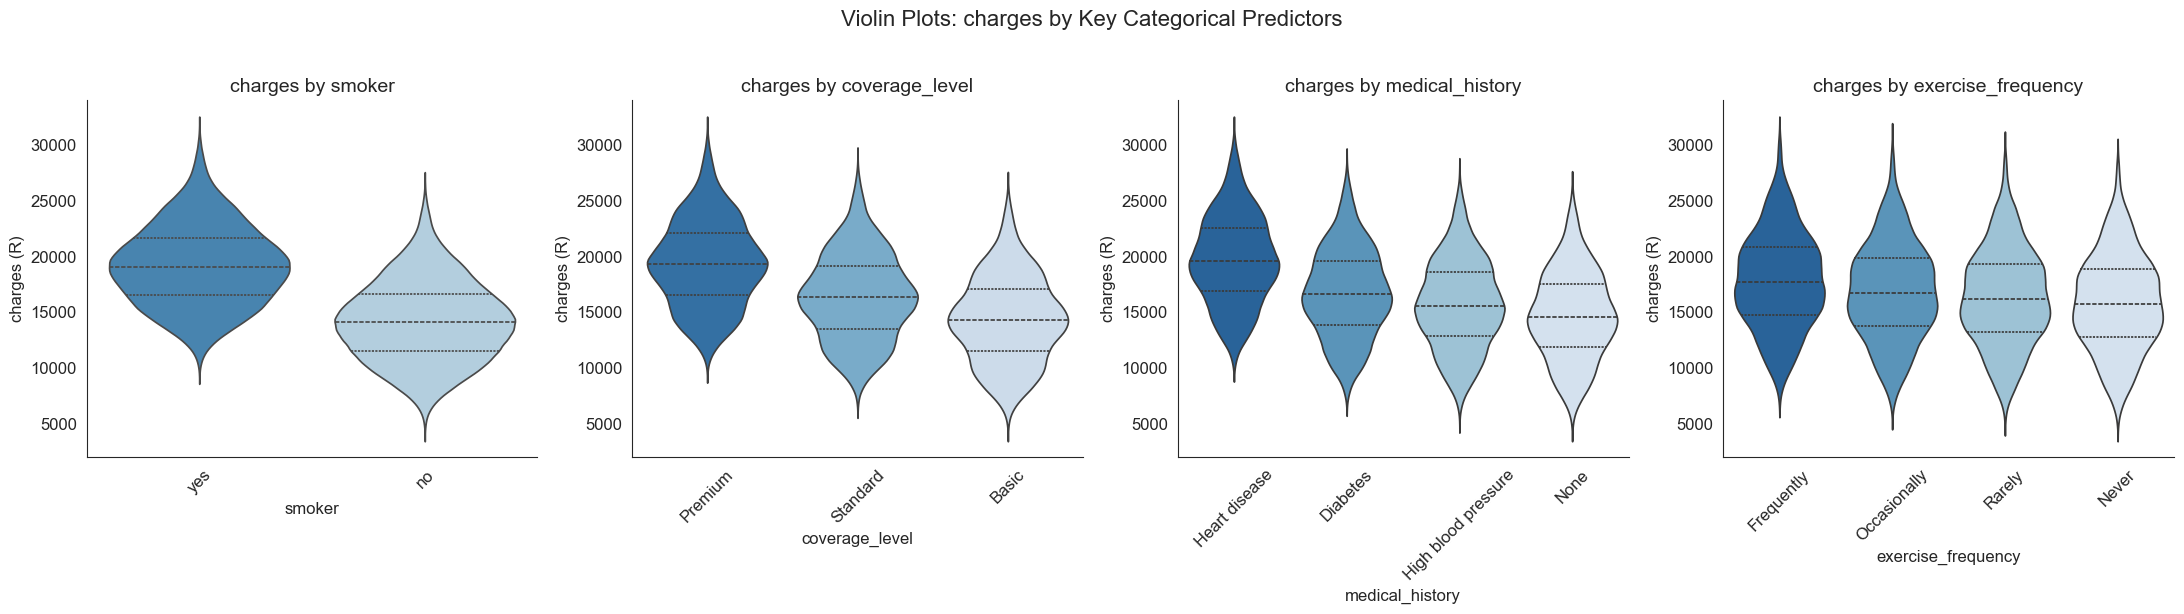

Figure saved: fig_charges_violin_plots.png


In [20]:
# 7.3 Violin plots for the four most influential categorical predictors
# Violin plots show the full density shape, not just the five-number summary
# This reveals multimodality and distribution shape differences between groups

key_cats = ['smoker', 'coverage_level', 'medical_history', 'exercise_frequency']
fig, axes = plt.subplots(1, 4, figsize=(22, 6))

for ax, col in zip(axes, key_cats):
    plot_df = df[[col, 'charges']].copy()
    plot_df[col] = plot_df[col].fillna('None')
    order = plot_df.groupby(col)['charges'].mean().sort_values(ascending=False).index
    sns.violinplot(data=plot_df, x=col, y='charges', order=order, ax=ax,
                   palette='Blues_r', inner='quartile', cut=0)
    ax.set_title(f'charges by {col}')
    ax.set_xlabel(col)
    ax.set_ylabel('charges (R)')
    ax.tick_params(axis='x', rotation=45)
    sns.despine(ax=ax)

plt.suptitle('Violin Plots: charges by Key Categorical Predictors', fontsize=16, y=1.02)
plt.tight_layout()
plt.savefig(FIG_DIR + 'fig_charges_violin_plots.png', dpi=300, bbox_inches='tight')
plt.show()
print('Figure saved: fig_charges_violin_plots.png')

## 7B. Interaction Effects

Two-way interactions between the strongest categorical predictors. These plots show whether the effect of one variable on charges depends on the level of another variable.

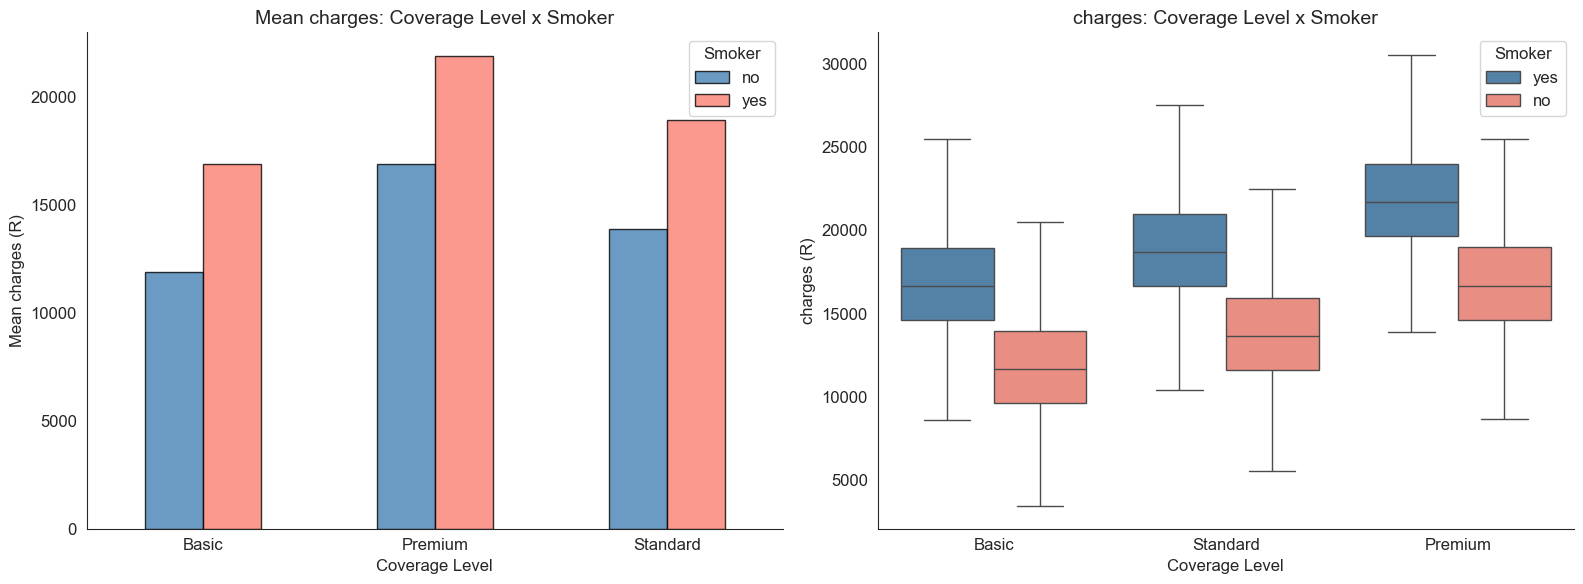

Figure saved: fig_interaction_smoker_coverage.png


In [21]:
# 7B.1 Interaction: smoker x coverage_level
# The two strongest categorical predictors of charges
# This reveals whether the smoker surcharge differs by coverage tier

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Grouped bar chart: mean charges
interact_1 = df.groupby(['coverage_level', 'smoker'])['charges'].mean().unstack()
interact_1.plot(kind='bar', ax=axes[0], color=['steelblue', 'salmon'], edgecolor='black', alpha=0.8)
axes[0].set_title('Mean charges: Coverage Level x Smoker')
axes[0].set_xlabel('Coverage Level')
axes[0].set_ylabel('Mean charges (R)')
axes[0].legend(title='Smoker')
axes[0].tick_params(axis='x', rotation=0)
sns.despine(ax=axes[0])

# Grouped boxplot
sns.boxplot(data=df, x='coverage_level', y='charges', hue='smoker', ax=axes[1],
            palette=['steelblue', 'salmon'], showfliers=False,
            order=['Basic', 'Standard', 'Premium'])
axes[1].set_title('charges: Coverage Level x Smoker')
axes[1].set_xlabel('Coverage Level')
axes[1].set_ylabel('charges (R)')
axes[1].legend(title='Smoker')
sns.despine(ax=axes[1])

plt.tight_layout()
plt.savefig(FIG_DIR + 'fig_interaction_smoker_coverage.png', dpi=300, bbox_inches='tight')
plt.show()
print('Figure saved: fig_interaction_smoker_coverage.png')

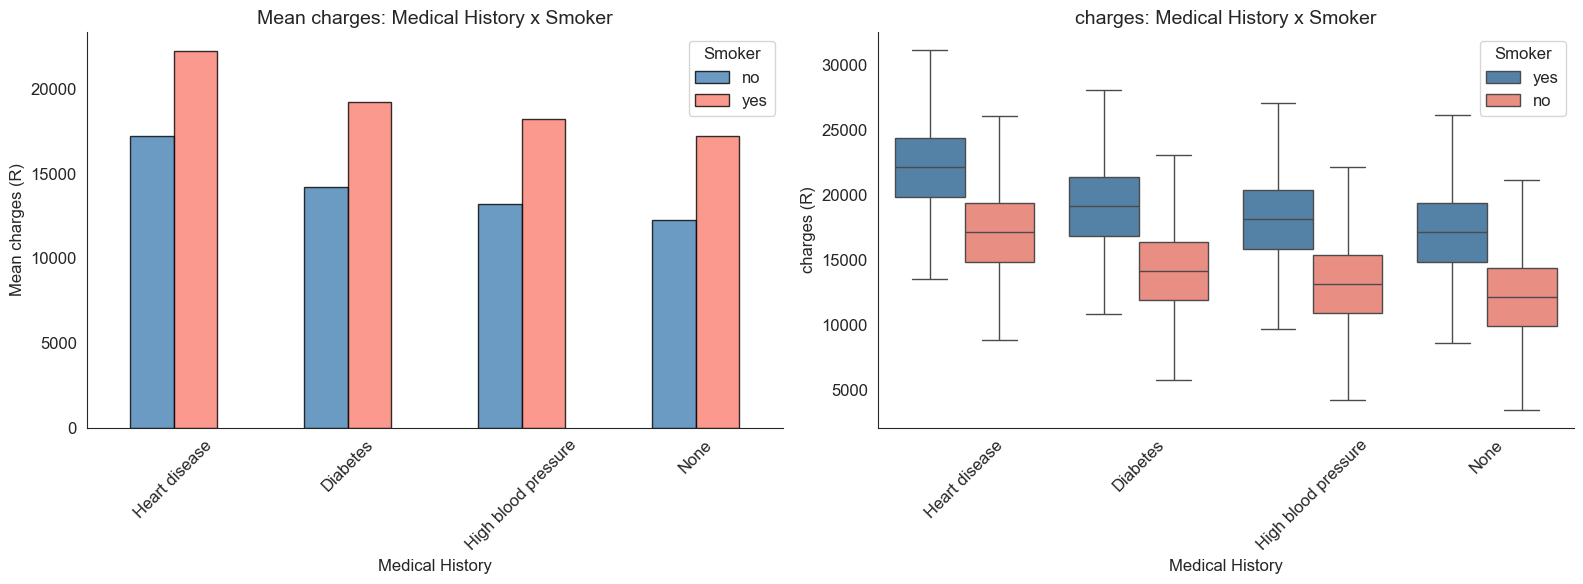

Figure saved: fig_interaction_smoker_medical.png


In [22]:
# 7B.2 Interaction: smoker x medical_history
# Investigates whether the effect of medical history on charges
# is amplified or attenuated by smoking status

plot_df = df[['smoker', 'medical_history', 'charges']].copy()
plot_df['medical_history'] = plot_df['medical_history'].fillna('None')

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Grouped bar chart: mean charges
interact_2 = plot_df.groupby(['medical_history', 'smoker'])['charges'].mean().unstack()
interact_2 = interact_2.loc[interact_2.mean(axis=1).sort_values(ascending=False).index]
interact_2.plot(kind='bar', ax=axes[0], color=['steelblue', 'salmon'], edgecolor='black', alpha=0.8)
axes[0].set_title('Mean charges: Medical History x Smoker')
axes[0].set_xlabel('Medical History')
axes[0].set_ylabel('Mean charges (R)')
axes[0].legend(title='Smoker')
axes[0].tick_params(axis='x', rotation=45)
sns.despine(ax=axes[0])

# Grouped boxplot
order = plot_df.groupby('medical_history')['charges'].mean().sort_values(ascending=False).index
sns.boxplot(data=plot_df, x='medical_history', y='charges', hue='smoker', ax=axes[1],
            palette=['steelblue', 'salmon'], showfliers=False, order=order)
axes[1].set_title('charges: Medical History x Smoker')
axes[1].set_xlabel('Medical History')
axes[1].set_ylabel('charges (R)')
axes[1].legend(title='Smoker')
axes[1].tick_params(axis='x', rotation=45)
sns.despine(ax=axes[1])

plt.tight_layout()
plt.savefig(FIG_DIR + 'fig_interaction_smoker_medical.png', dpi=300, bbox_inches='tight')
plt.show()
print('Figure saved: fig_interaction_smoker_medical.png')

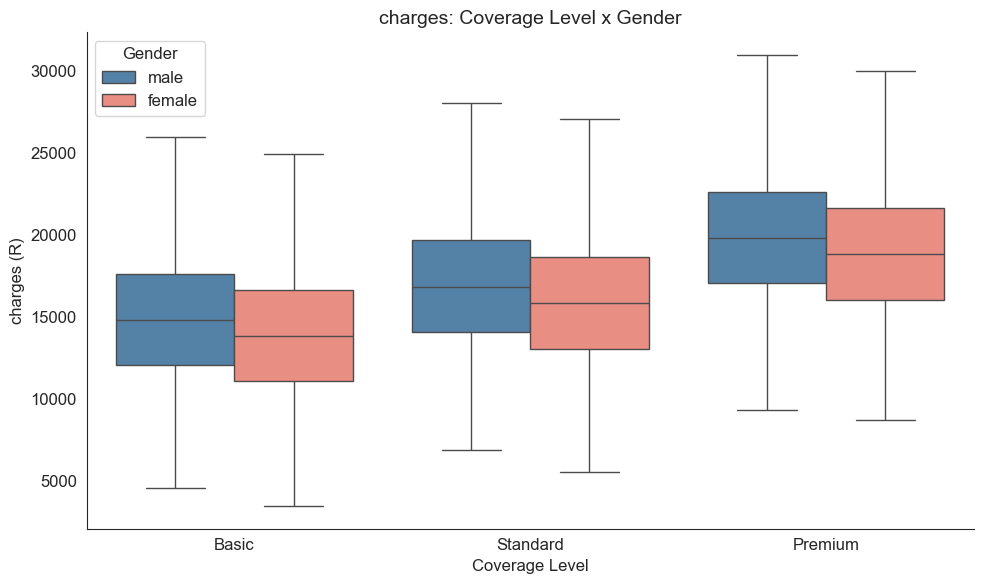

Figure saved: fig_interaction_coverage_gender.png


In [23]:
# 7B.3 Interaction: coverage_level x gender
# Checks whether the coverage-tier premium structure differs by gender

fig, ax = plt.subplots(figsize=(10, 6))
sns.boxplot(data=df, x='coverage_level', y='charges', hue='gender', ax=ax,
            palette=['steelblue', 'salmon'], showfliers=False,
            order=['Basic', 'Standard', 'Premium'])
ax.set_title('charges: Coverage Level x Gender')
ax.set_xlabel('Coverage Level')
ax.set_ylabel('charges (R)')
ax.legend(title='Gender')
sns.despine()
plt.tight_layout()
plt.savefig(FIG_DIR + 'fig_interaction_coverage_gender.png', dpi=300, bbox_inches='tight')
plt.show()
print('Figure saved: fig_interaction_coverage_gender.png')

## 8. Correlation Analysis

Pairwise correlations among numeric variables and a heatmap visualisation.

In [24]:
# 8.1 Pearson correlation matrix for numeric variables
# The numeric predictors are approximately uncorrelated with one another (|r| < 0.01)
# Marginal correlations with charges are weak (r = 0.06 to 0.10)

corr_matrix = df[numeric_cols].corr()
print('=== Pearson Correlation Matrix ===')
print(corr_matrix.round(4))

=== Pearson Correlation Matrix ===
             age     bmi  children  charges
age       1.0000  0.0014   -0.0013   0.0634
bmi       0.0014  1.0000   -0.0016   0.1044
children -0.0013 -0.0016    1.0000   0.0768
charges   0.0634  0.1044    0.0768   1.0000


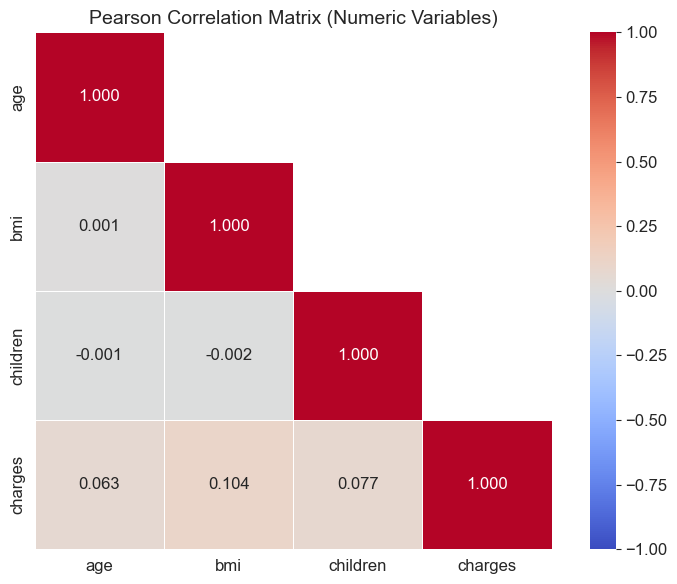

Figure saved: fig_correlation_heatmap.png


In [25]:
# 8.2 Correlation heatmap
# Visualises the weak linear associations among numeric variables

fig, ax = plt.subplots(figsize=(8, 6))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)
sns.heatmap(corr_matrix, annot=True, fmt='.3f', cmap='coolwarm',
            center=0, vmin=-1, vmax=1, mask=mask, ax=ax,
            square=True, linewidths=0.5)
ax.set_title('Pearson Correlation Matrix (Numeric Variables)')
plt.tight_layout()
plt.savefig(FIG_DIR + 'fig_correlation_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()
print('Figure saved: fig_correlation_heatmap.png')

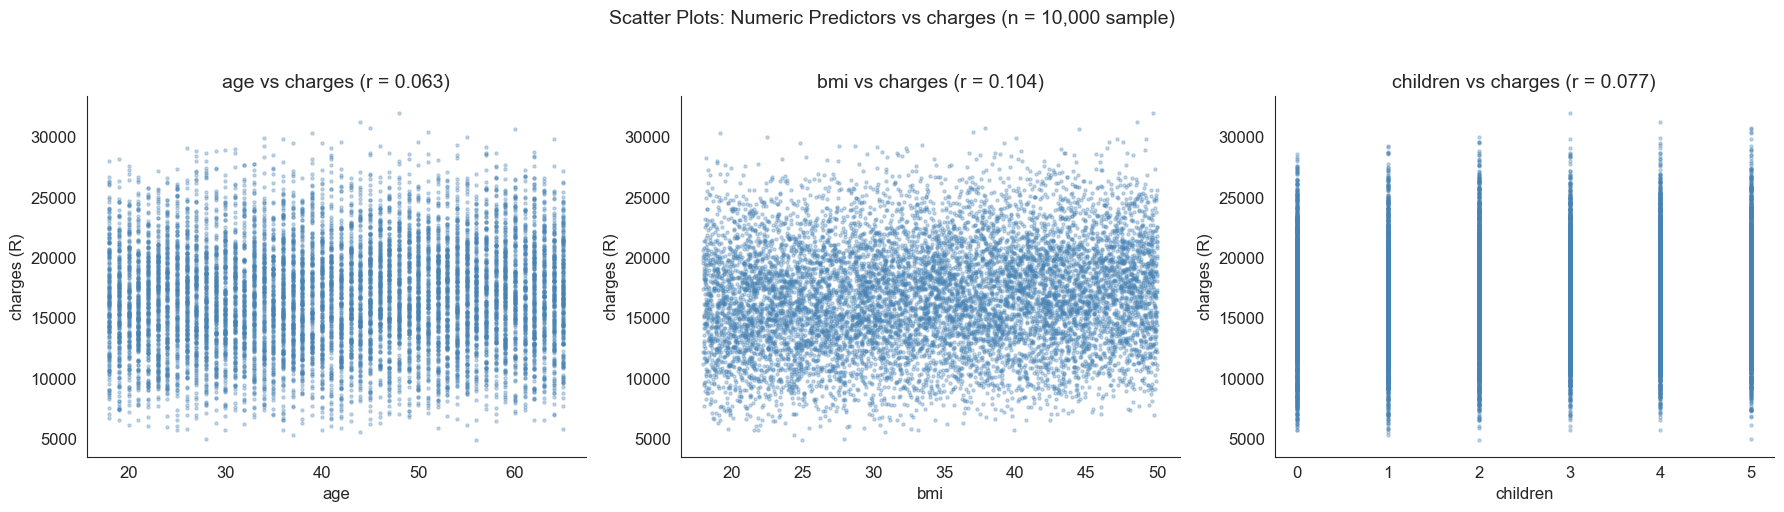

Figure saved: fig_scatter_numeric_vs_charges.png


In [26]:
# 8.3 Scatter plots: each numeric predictor vs charges
# Low linear correlations do not preclude nonlinear relationships
# which the DNN can capture

pred_numeric = ['age', 'bmi', 'children']
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Use a random sample for plotting to avoid overplotting with 1M points
sample = df.sample(n=10_000, random_state=42)

for ax, col in zip(axes, pred_numeric):
    ax.scatter(sample[col], sample['charges'], alpha=0.3, s=5, color='steelblue')
    ax.set_title(f'{col} vs charges (r = {corr_matrix.loc[col, "charges"]:.3f})')
    ax.set_xlabel(col)
    ax.set_ylabel('charges (R)')
    sns.despine(ax=ax)

plt.suptitle('Scatter Plots: Numeric Predictors vs charges (n = 10,000 sample)',
             fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig(FIG_DIR + 'fig_scatter_numeric_vs_charges.png', dpi=300, bbox_inches='tight')
plt.show()
print('Figure saved: fig_scatter_numeric_vs_charges.png')

## 9. Post-Encoding Diagnostics (Model-Ready Data)

Verification that the encoding and train/validation/test partitioning did not introduce artefacts.

In [27]:
# 9.1 Load the three model-ready split files produced by SamplingForML
# These contain 23 columns: 22 encoded predictors + charges (response)

TRAIN_PATH = '/Users/baloyithabangbonganijunior/Downloads/model_ready_charges_train_20260517_115748.csv'
VALI_PATH  = '/Users/baloyithabangbonganijunior/Downloads/model_ready_charges_vali_20260517_115748.csv'
TEST_PATH  = '/Users/baloyithabangbonganijunior/Downloads/model_ready_charges_test_20260517_115748.csv'

train = pd.read_csv(TRAIN_PATH)
vali  = pd.read_csv(VALI_PATH)
test  = pd.read_csv(TEST_PATH)

print(f'Training set:   {len(train):>10,} rows x {train.shape[1]} cols  ({len(train)/1_000_000*100:.2f}%)')
print(f'Validation set: {len(vali):>10,} rows x {vali.shape[1]} cols  ({len(vali)/1_000_000*100:.2f}%)')
print(f'Test set:       {len(test):>10,} rows x {test.shape[1]} cols  ({len(test)/1_000_000*100:.2f}%)')
print(f'Total:          {len(train)+len(vali)+len(test):>10,}')

Training set:      524,288 rows x 23 cols  (52.43%)
Validation set:    237,856 rows x 23 cols  (23.79%)
Test set:          237,856 rows x 23 cols  (23.79%)
Total:           1,000,000


In [28]:
# 9.2 Verify no missing values in any of the model-ready files
# All NaN in medical_history and family_medical_history should now be
# encoded as the reference category (all dummy columns = 0)

for name, dataset in [('Train', train), ('Validation', vali), ('Test', test)]:
    n_missing = dataset.isnull().sum().sum()
    print(f'{name}: {n_missing} missing values')

Train: 0 missing values
Validation: 0 missing values
Test: 0 missing values


In [29]:
# 9.3 Display the encoded column names
# 22 predictors + 1 response = 23 columns
# Input dimension for the DNN: d_0 = p = 22

print(f'Number of columns: {train.shape[1]}')
print(f'Number of predictors (p): {train.shape[1] - 1}')
print(f'\nColumn names:')
for i, col in enumerate(train.columns, 1):
    print(f'  {i:2d}. {col}')

Number of columns: 23
Number of predictors (p): 22

Column names:
   1. charges
   2. age
   3. gender
   4. bmi
   5. children
   6. smoker
   7. region_southwest
   8. region_northwest
   9. region_southeast
  10. medical_history_Heart_disease
  11. medical_history_High_blood_pressure
  12. medical_history_Diabetes
  13. family_medical_history_Heart_disease
  14. family_medical_history_High_blood_pressure
  15. family_medical_history_Diabetes
  16. exercise_frequency_Occasionally
  17. exercise_frequency_Frequently
  18. exercise_frequency_Never
  19. occupation_Student
  20. occupation_Blue_collar
  21. occupation_White_collar
  22. coverage_level_Standard
  23. coverage_level_Premium


In [30]:
# 9.4 Compare dummy-column proportions across splits
# Proportions should be consistent with the full-sample frequencies
# to confirm no systematic distributional shifts from partitioning

dummy_cols = [c for c in train.columns if c not in ['charges', 'age', 'bmi', 'children']]

comparison = pd.DataFrame({
    'Train': train[dummy_cols].mean(),
    'Validation': vali[dummy_cols].mean(),
    'Test': test[dummy_cols].mean()
}).round(4)

print('=== Dummy-Column Proportions Across Splits ===')
print(comparison)

=== Dummy-Column Proportions Across Splits ===
                                            Train  Validation   Test
gender                                     0.4997      0.5004 0.4999
smoker                                     0.5002      0.5007 0.4994
region_southwest                           0.2506      0.2499 0.2492
region_northwest                           0.2494      0.2506 0.2505
region_southeast                           0.2502      0.2486 0.2495
medical_history_Heart_disease              0.2502      0.2502 0.2499
medical_history_High_blood_pressure        0.2492      0.2516 0.2492
medical_history_Diabetes                   0.2495      0.2483 0.2501
family_medical_history_Heart_disease       0.2497      0.2503 0.2505
family_medical_history_High_blood_pressure 0.2491      0.2506 0.2506
family_medical_history_Diabetes            0.2508      0.2485 0.2486
exercise_frequency_Occasionally            0.2504      0.2505 0.2501
exercise_frequency_Frequently              0.2502      0

In [31]:
# 9.5 Compare charges distribution across splits
# Training-set statistics should be consistent with full-sample values

charges_comparison = pd.DataFrame({
    'Full': df['charges'].describe(),
    'Train': train['charges'].describe(),
    'Validation': vali['charges'].describe(),
    'Test': test['charges'].describe()
}).round(2)

print('=== charges Distribution Across Splits ===')
print(charges_comparison)

=== charges Distribution Across Splits ===
                Full        Train   Validation         Test
count 1,000,000.0000 524,288.0000 237,856.0000 237,856.0000
mean     16,735.1200  16,739.5200  16,736.0100  16,724.5300
std       4,415.8100   4,415.9900   4,421.7700   4,409.4400
min       3,445.0100   3,886.8800   3,445.0100   4,161.9600
25%      13,600.3700  13,608.6700  13,577.7900  13,605.3400
50%      16,622.1300  16,625.9700  16,620.9000  16,614.3900
75%      19,781.4700  19,788.4800  19,793.5800  19,753.1600
max      32,561.5600  32,495.0700  32,561.5600  32,168.5400


In [32]:
# 9.6 Correlation of each encoded predictor with charges in the training set
# Strongest linear associations: smoker (0.567), coverage_level_Premium (0.427),
# medical_history_Heart_disease (0.393), family_medical_history_Heart_disease (0.393)

pred_cols = [c for c in train.columns if c != 'charges']
corrs = train[pred_cols].corrwith(train['charges']).sort_values(ascending=False)

print('=== Correlation of Encoded Predictors with charges (Training Set) ===')
for var, r in corrs.items():
    bar = '+' * int(abs(r) * 40)
    sign = '+' if r > 0 else '-'
    print(f'  {var:50s} r = {r:+.4f}  {sign}{bar}')

=== Correlation of Encoded Predictors with charges (Training Set) ===
  smoker                                             r = +0.5665  +++++++++++++++++++++++
  coverage_level_Premium                             r = +0.4265  ++++++++++++++++++
  medical_history_Heart_disease                      r = +0.3929  ++++++++++++++++
  family_medical_history_Heart_disease               r = +0.3925  ++++++++++++++++
  exercise_frequency_Frequently                      r = +0.1467  ++++++
  occupation_White_collar                            r = +0.1293  ++++++
  bmi                                                r = +0.1058  +++++
  children                                           r = +0.0781  ++++
  occupation_Blue_collar                             r = +0.0662  +++
  age                                                r = +0.0650  +++
  exercise_frequency_Occasionally                    r = +0.0156  +
  medical_history_Diabetes                           r = +0.0018  +
  region_southeast      

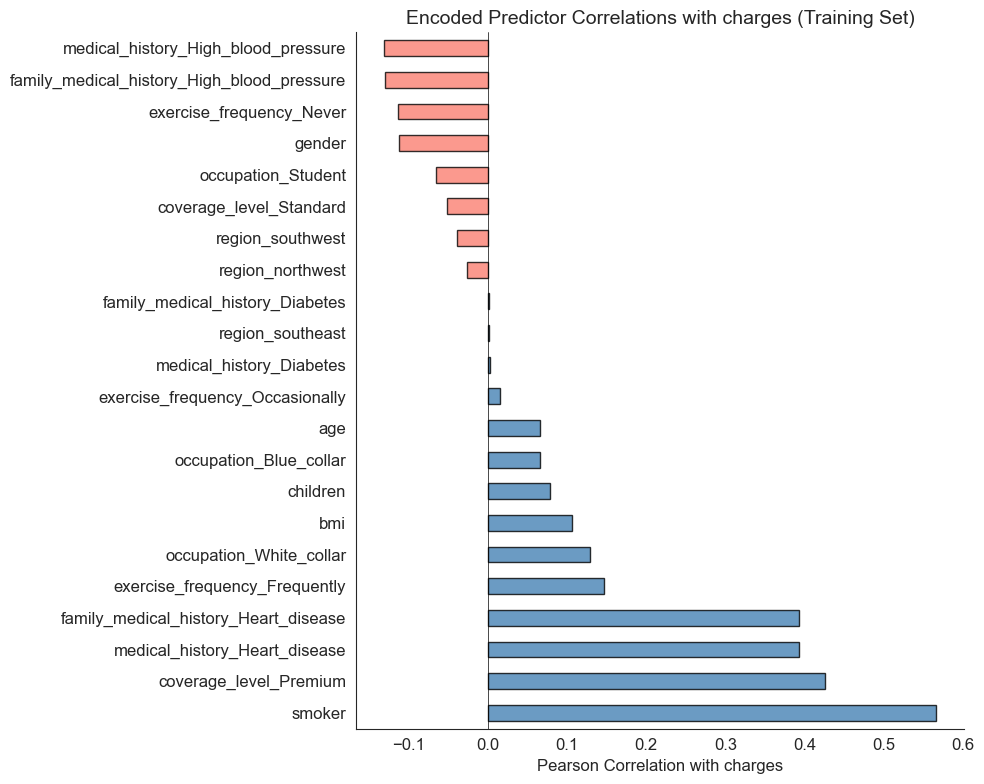

Figure saved: fig_encoded_correlations.png


In [33]:
# 9.7 Correlation bar chart for encoded predictors vs charges
# Visualises the ranking of linear associations with the response

fig, ax = plt.subplots(figsize=(10, 8))
colors = ['steelblue' if r > 0 else 'salmon' for r in corrs.values]
corrs.plot(kind='barh', ax=ax, color=colors, edgecolor='black', alpha=0.8)
ax.set_xlabel('Pearson Correlation with charges')
ax.set_title('Encoded Predictor Correlations with charges (Training Set)')
ax.axvline(0, color='black', linewidth=0.5)
sns.despine()
plt.tight_layout()
plt.savefig(FIG_DIR + 'fig_encoded_correlations.png', dpi=300, bbox_inches='tight')
plt.show()
print('Figure saved: fig_encoded_correlations.png')

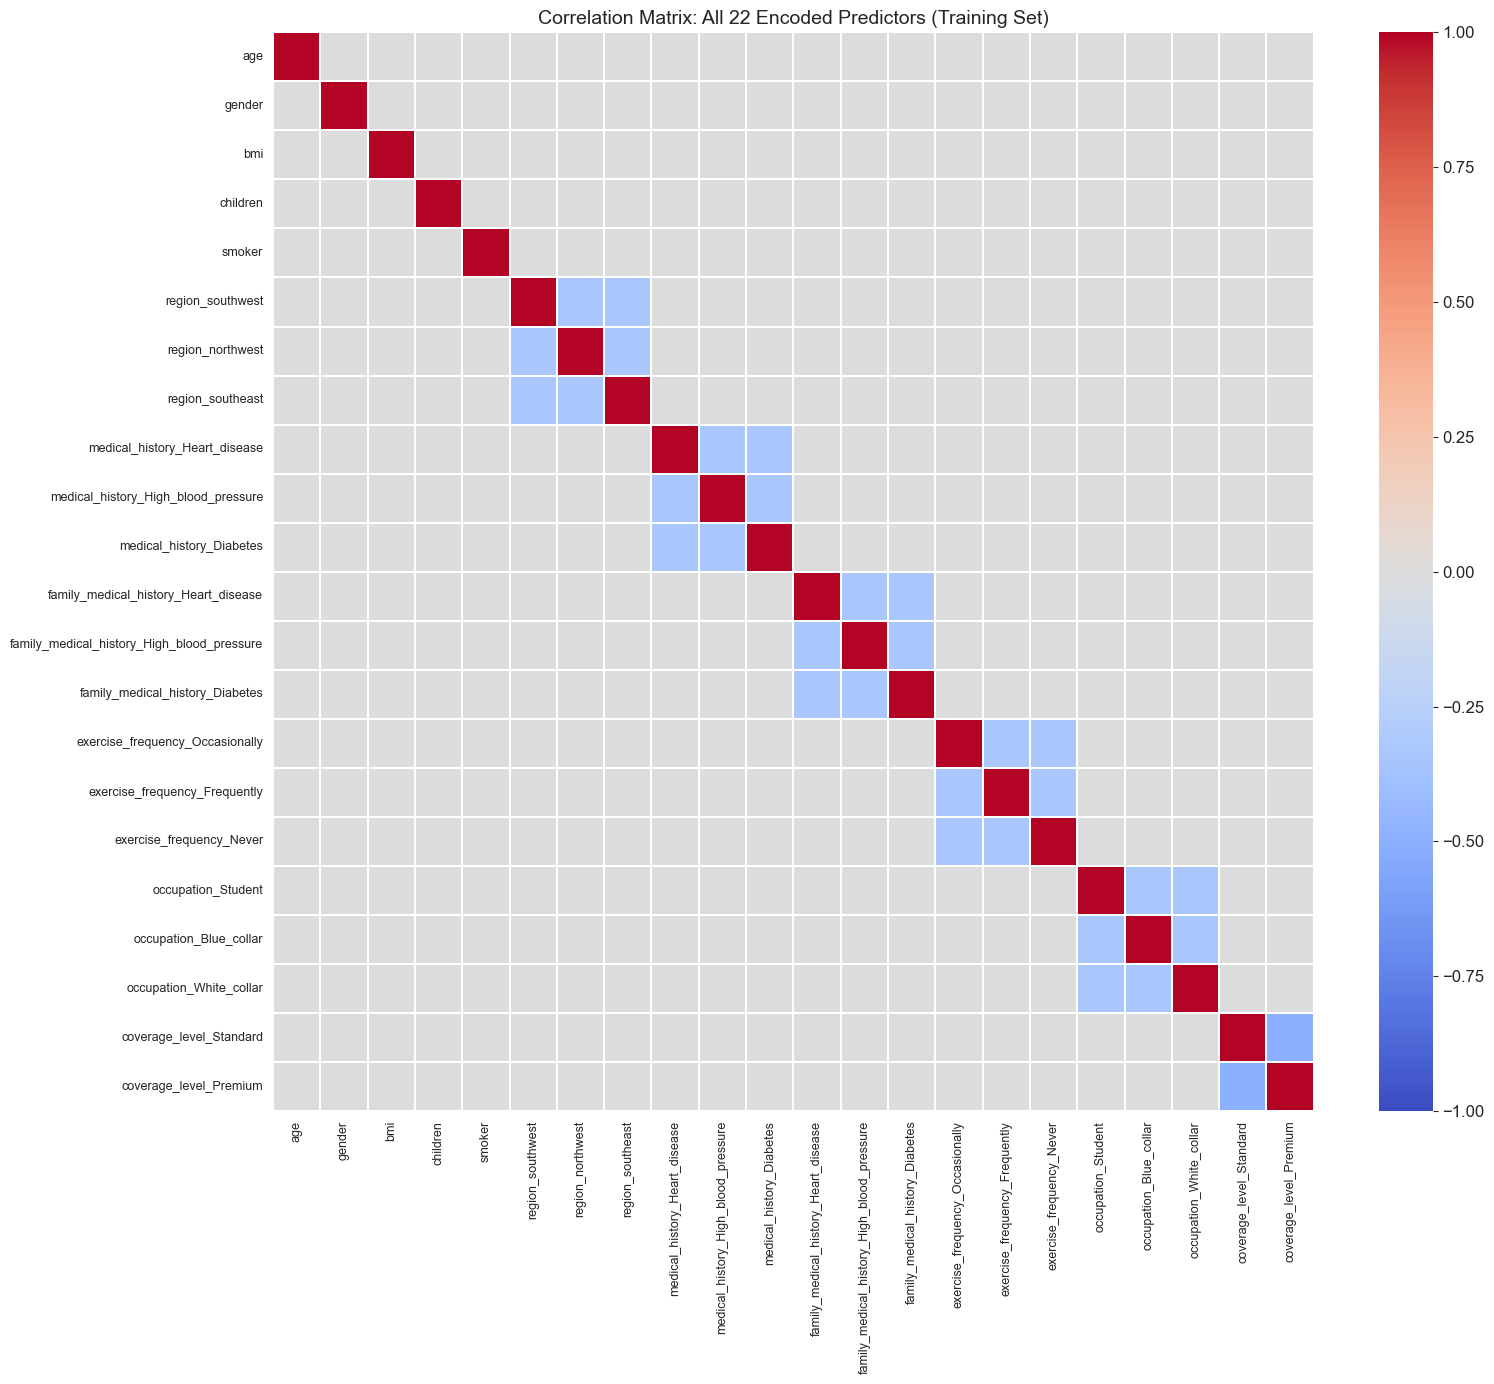

Figure saved: fig_full_encoded_correlation_heatmap.png


In [34]:
# 9.8 Full correlation heatmap for all 22 encoded predictors (training set)
# Reveals multicollinearity structure among the encoded input features

fig, ax = plt.subplots(figsize=(16, 14))
full_corr = train[pred_cols].corr()
sns.heatmap(full_corr, cmap='coolwarm', center=0, vmin=-1, vmax=1,
            ax=ax, linewidths=0.3, fmt='.2f',
            xticklabels=True, yticklabels=True)
ax.set_title('Correlation Matrix: All 22 Encoded Predictors (Training Set)', fontsize=14)
ax.tick_params(axis='x', rotation=90, labelsize=9)
ax.tick_params(axis='y', rotation=0, labelsize=9)
plt.tight_layout()
plt.savefig(FIG_DIR + 'fig_full_encoded_correlation_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()
print('Figure saved: fig_full_encoded_correlation_heatmap.png')

## 10. Split-Consistency Check

Overlaid KDE density plots confirming that the train, validation and test splits share the same distributional characteristics across key variables.

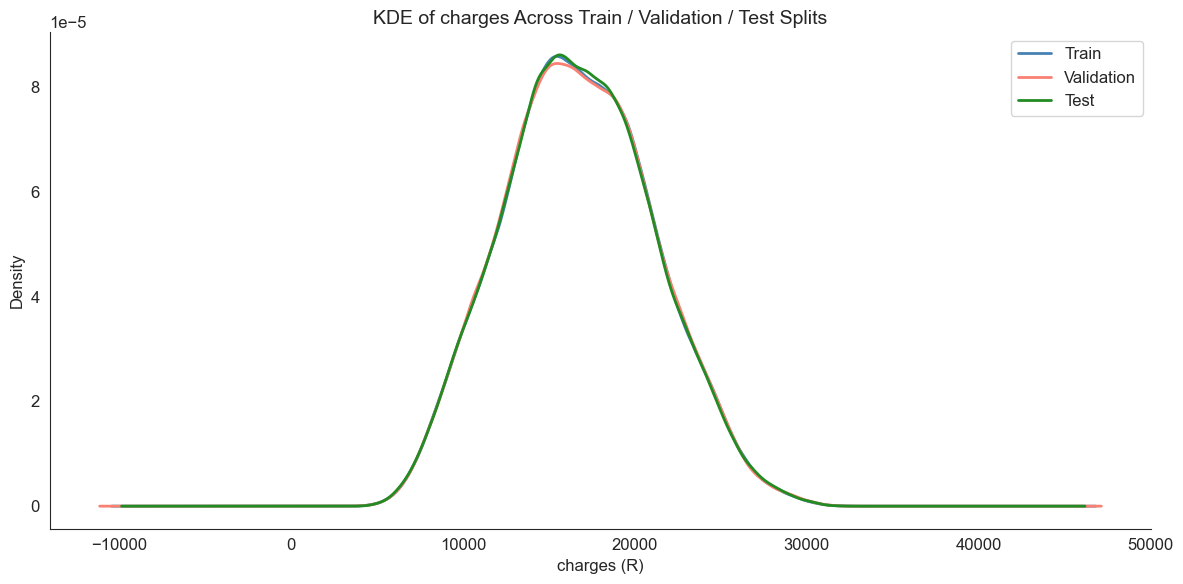

Figure saved: fig_split_charges_kde.png


In [35]:
# 10.1 Overlaid KDE plots for charges across the three splits
# If the partitioning is sound, the three density curves should overlap almost perfectly

fig, ax = plt.subplots(figsize=(12, 6))
train['charges'].plot.kde(ax=ax, color='steelblue', linewidth=2, label='Train')
vali['charges'].plot.kde(ax=ax, color='salmon', linewidth=2, label='Validation')
test['charges'].plot.kde(ax=ax, color='forestgreen', linewidth=2, label='Test')
ax.set_title('KDE of charges Across Train / Validation / Test Splits')
ax.set_xlabel('charges (R)')
ax.set_ylabel('Density')
ax.legend()
sns.despine()
plt.tight_layout()
plt.savefig(FIG_DIR + 'fig_split_charges_kde.png', dpi=300, bbox_inches='tight')
plt.show()
print('Figure saved: fig_split_charges_kde.png')

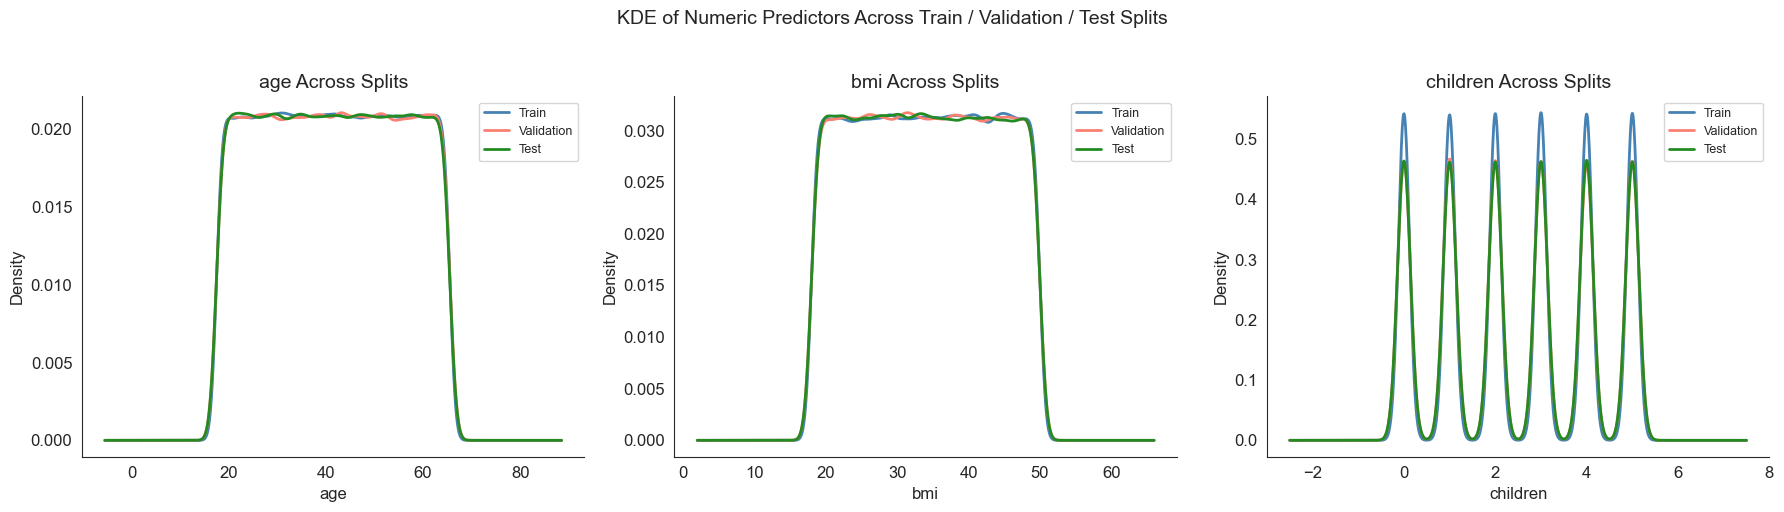

Figure saved: fig_split_numeric_kde.png


In [36]:
# 10.2 Overlaid KDE plots for the three numeric predictors across splits
# Confirms distributional consistency for age, bmi and children

cont_cols = ['age', 'bmi', 'children']
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, col in zip(axes, cont_cols):
    train[col].plot.kde(ax=ax, color='steelblue', linewidth=2, label='Train')
    vali[col].plot.kde(ax=ax, color='salmon', linewidth=2, label='Validation')
    test[col].plot.kde(ax=ax, color='forestgreen', linewidth=2, label='Test')
    ax.set_title(f'{col} Across Splits')
    ax.set_xlabel(col)
    ax.set_ylabel('Density')
    ax.legend(fontsize=9)
    sns.despine(ax=ax)

plt.suptitle('KDE of Numeric Predictors Across Train / Validation / Test Splits',
             fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig(FIG_DIR + 'fig_split_numeric_kde.png', dpi=300, bbox_inches='tight')
plt.show()
print('Figure saved: fig_split_numeric_kde.png')

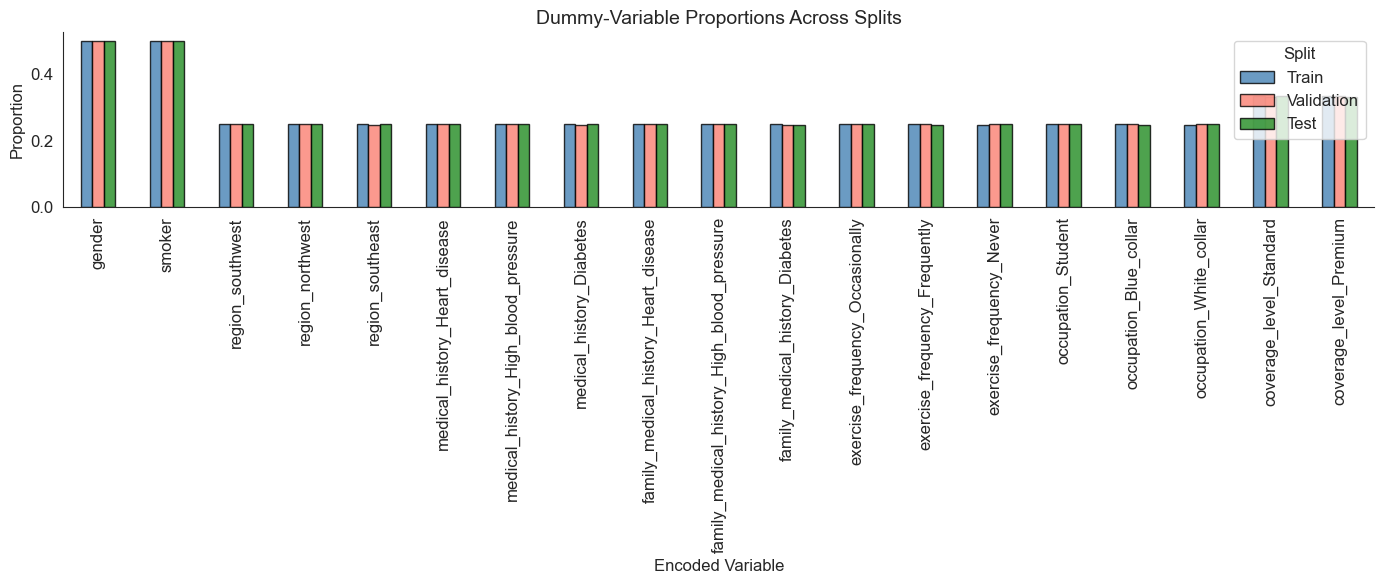

Figure saved: fig_split_dummy_proportions.png


In [37]:
# 10.3 Grouped bar chart: dummy-column proportions across splits
# Visually confirms that the categorical distributions are preserved after splitting

fig, ax = plt.subplots(figsize=(14, 6))
comparison.plot(kind='bar', ax=ax, edgecolor='black', alpha=0.8,
                color=['steelblue', 'salmon', 'forestgreen'])
ax.set_title('Dummy-Variable Proportions Across Splits')
ax.set_xlabel('Encoded Variable')
ax.set_ylabel('Proportion')
ax.legend(title='Split')
ax.tick_params(axis='x', rotation=90)
sns.despine()
plt.tight_layout()
plt.savefig(FIG_DIR + 'fig_split_dummy_proportions.png', dpi=300, bbox_inches='tight')
plt.show()
print('Figure saved: fig_split_dummy_proportions.png')

## 11. Principal Component Analysis of the Model-Ready Input Space

### 11.1 Mathematical Formulation

Let $\mathbf{X} \in \mathbb{R}^{n \times p}$ denote the column-standardised (zero mean, unit variance) model-ready input matrix, where $n$ is the number of observations and $p = 22$ is the number of encoded predictors.

**Step 1 -- Sample covariance matrix.**  
The sample covariance matrix is

$$\mathbf{S} = \frac{1}{n-1}\,\mathbf{X}^{\!\top}\mathbf{X} \;\in\; \mathbb{R}^{p \times p}.$$

Because the inputs are standardised, $\mathbf{S}$ is the Pearson correlation matrix of the predictors.

**Step 2 -- Eigenvalue decomposition.**  
The spectral decomposition of $\mathbf{S}$ is

$$\mathbf{S} = \mathbf{W}\,\boldsymbol{\Lambda}\,\mathbf{W}^{\!\top}, \qquad \boldsymbol{\Lambda} = \operatorname{diag}(\lambda_1,\ldots,\lambda_p), \quad \lambda_1 \geq \lambda_2 \geq \cdots \geq \lambda_p \geq 0,$$

where $\mathbf{W} = [\,\mathbf{w}_1 \;\cdots\; \mathbf{w}_p\,]$ is the orthogonal matrix of eigenvectors and $\lambda_k$ is the variance captured by the $k$-th principal component.

**Step 3 -- Principal component scores.**  
The $k$-th principal component score for observation $i$ is

$$z_{ik} = \mathbf{x}_i^{\!\top}\,\mathbf{w}_k, \qquad k = 1,\ldots,p.$$

Projecting onto the first two components yields the two-dimensional representation $\mathbf{z}_i = (z_{i1},\, z_{i2})$ used in the scatter plots below.

**Step 4 -- Explained variance ratio.**  
The proportion of total variance explained by the $k$-th component is

$$\text{EVR}_k = \frac{\lambda_k}{\sum_{j=1}^{p}\lambda_j}.$$

### 11.2 PCA Loadings and Their Importance

The **loading vector** $\mathbf{w}_k = (w_{1k},\ldots,w_{pk})^{\!\top}$ is the $k$-th eigenvector of $\mathbf{S}$. The entry $w_{jk}$ quantifies the contribution of the $j$-th standardised predictor to the $k$-th principal component:

- A **large positive** $w_{jk}$ means that predictor $j$ increases the PC$k$ score.
- A **large negative** $w_{jk}$ means that predictor $j$ decreases the PC$k$ score.
- A value **near zero** means that predictor $j$ has negligible influence on PC$k$.

**Why loadings matter for this dissertation:**

1. **Structural insight.** The loadings reveal which predictors dominate the low-dimensional structure of the input space. If, for example, `smoker` and `coverage_level_Premium` carry the largest absolute loadings on PC1, then the primary axis of variation in the standardised inputs is driven by smoking status and coverage tier, aligning with the conditional analysis in Section 7.

2. **Consistency with Shapley values.** Features that load heavily on the first principal components are expected to appear as important in the SHAP analysis (Chapter 4), because they account for the most variation in the input space that the DNN must resolve.

3. **Partition diagnostics.** When the same PCA projection is applied to both training and test data, similar point-cloud shapes confirm that the random partition preserved the covariance structure of the inputs.

4. **Model capture diagnostic.** In the training notebook (Section 13.5), the same PC coordinates are coloured by actual and predicted targets. If the colour gradients match, the DNN has captured the dominant target structure visible in the input space.

**Note:** PCA is used here purely as a diagnostic tool. No predictors are removed; the full set of $p = 22$ features is retained for DNN training.

Explained variance ratio: PC1 = 6.82%, PC2 = 6.10%
Cumulative (2 components): 12.93%
Eigenvalues: lambda_1 = 1.5013, lambda_2 = 1.3428


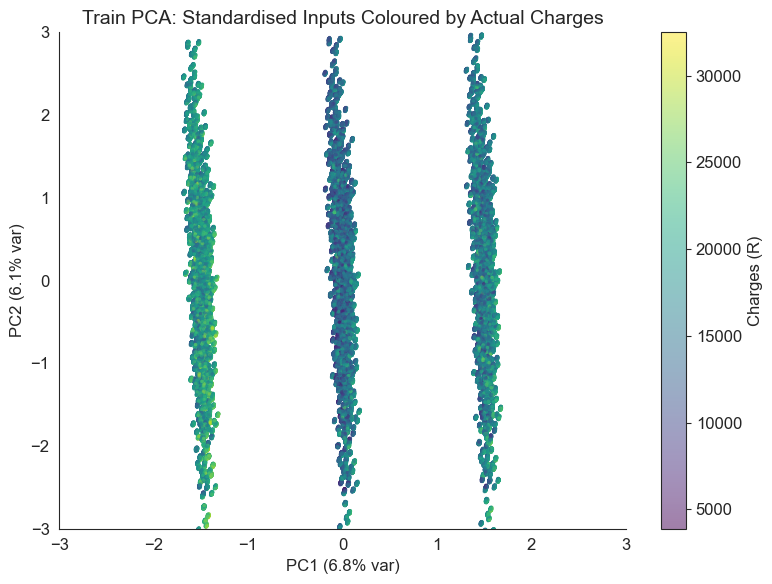

Figure saved: fig_eda_pca_train_actual.png


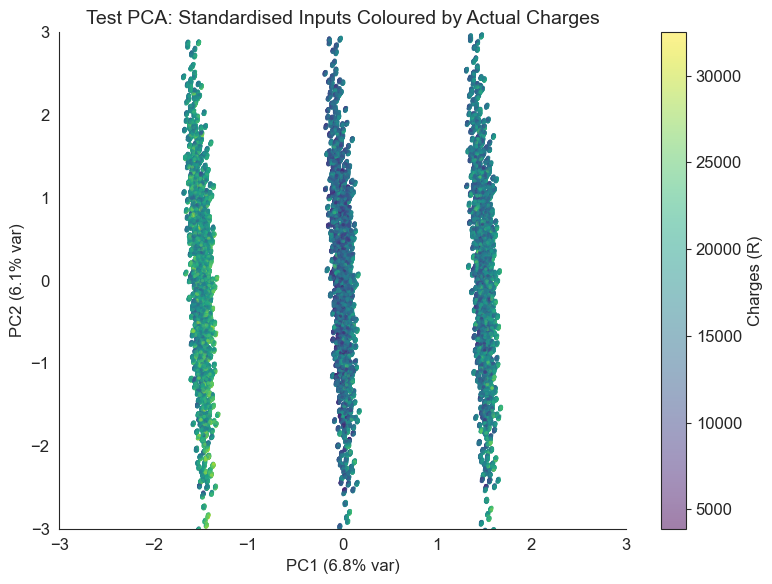

Figure saved: fig_eda_pca_test_actual.png


In [38]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# --- Standardise the model-ready inputs (training-set parameters only) ---
FEATURES = [c for c in train.columns if c != 'charges']

scaler = StandardScaler()
X_train_std = scaler.fit_transform(train[FEATURES].values)
X_test_std  = scaler.transform(test[FEATURES].values)

# --- Fit PCA on the standardised training inputs ---
pca = PCA(n_components=2, random_state=42)
pca.fit(X_train_std)

pc_train = pca.transform(X_train_std)
pc_test  = pca.transform(X_test_std)

ev1 = pca.explained_variance_ratio_[0] * 100
ev2 = pca.explained_variance_ratio_[1] * 100

print(f'Explained variance ratio: PC1 = {ev1:.2f}%, PC2 = {ev2:.2f}%')
print(f'Cumulative (2 components): {ev1 + ev2:.2f}%')
print(f'Eigenvalues: lambda_1 = {pca.explained_variance_[0]:.4f}, '
      f'lambda_2 = {pca.explained_variance_[1]:.4f}')

# --- Shared colour limits for consistent colouring ---
y_train_vals = train['charges'].values
y_test_vals  = test['charges'].values
vmin = min(y_train_vals.min(), y_test_vals.min())
vmax = max(y_train_vals.max(), y_test_vals.max())

axis_lim = 3

# --- Helper function ---
def plot_pca_scatter(pc_coords, colour_values, title, cbar_label, save_name):
    fig, ax = plt.subplots(figsize=(8, 6))
    sc = ax.scatter(
        pc_coords[:, 0], pc_coords[:, 1],
        c=colour_values, cmap='viridis', s=6, alpha=0.5,
        vmin=vmin, vmax=vmax, edgecolors='none'
    )
    ax.set_xlim(-axis_lim, axis_lim)
    ax.set_ylim(-axis_lim, axis_lim)
    ax.set_xlabel(f'PC1 ({ev1:.1f}% var)')
    ax.set_ylabel(f'PC2 ({ev2:.1f}% var)')
    ax.set_title(title)
    plt.colorbar(sc, ax=ax, label=cbar_label)
    sns.despine(ax=ax)
    plt.tight_layout()
    plt.savefig(FIG_DIR + save_name, dpi=300, bbox_inches='tight')
    plt.show()
    print(f'Figure saved: {save_name}')


# --- PCA scatter: Training set coloured by actual charges ---
plot_pca_scatter(
    pc_train, y_train_vals,
    title='Train PCA: Standardised Inputs Coloured by Actual Charges',
    cbar_label='Charges (R)',
    save_name='fig_eda_pca_train_actual.png'
)

# --- PCA scatter: Test set coloured by actual charges ---
plot_pca_scatter(
    pc_test, y_test_vals,
    title='Test PCA: Standardised Inputs Coloured by Actual Charges',
    cbar_label='Charges (R)',
    save_name='fig_eda_pca_test_actual.png'
)

### 11.3 PCA Loading Vectors

The bar charts below display $w_{j1}$ and $w_{j2}$ for every predictor $j = 1,\ldots,22$, sorted by absolute magnitude. Features with the largest $|w_{jk}|$ are the primary drivers of the $k$-th principal component direction.

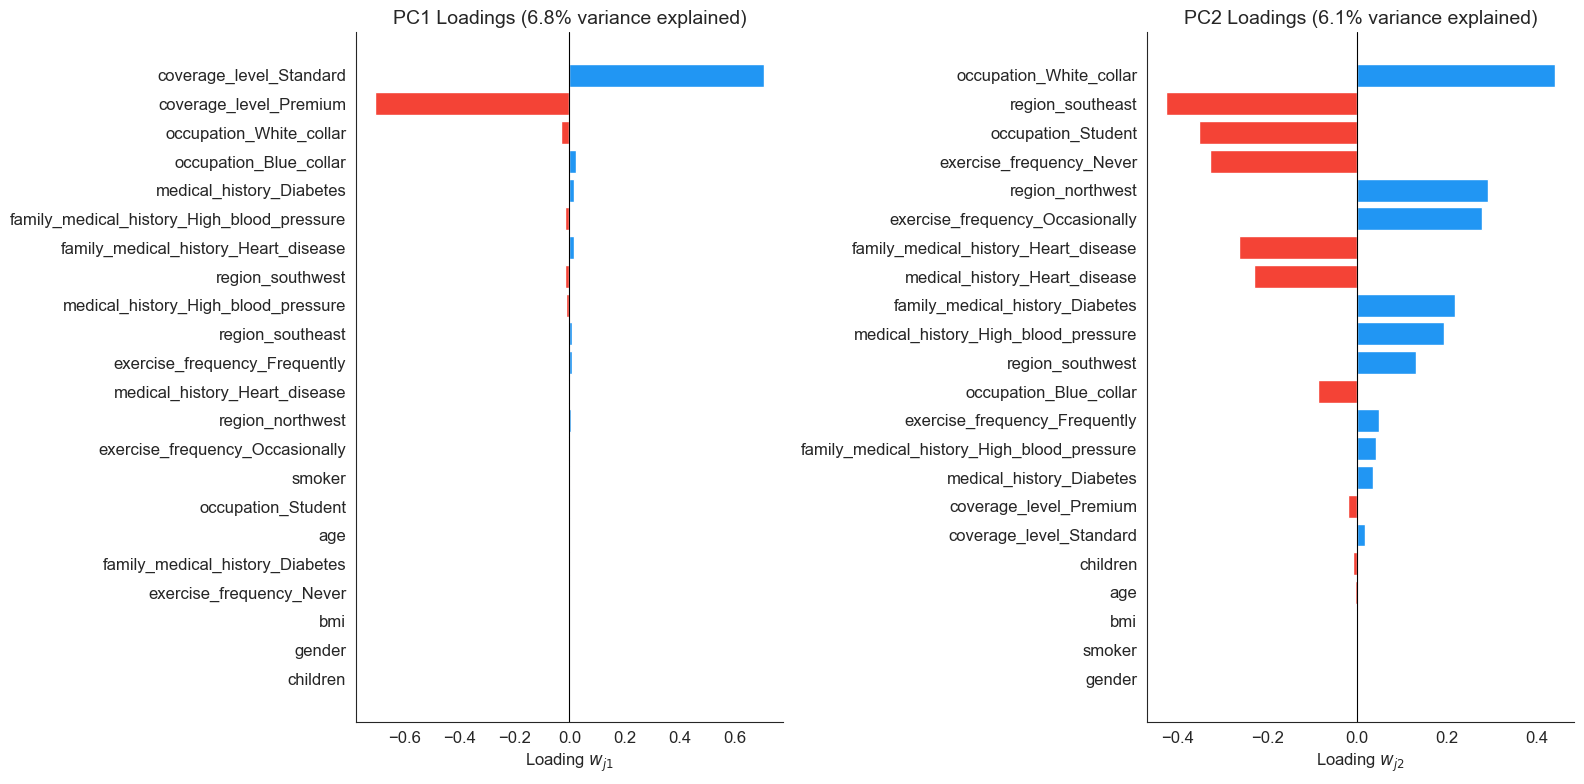

Figure saved: fig_eda_pca_loadings.png

FULL PCA LOADINGS TABLE (sorted by |w_j1|)
Feature                                       w_j1 (PC1) w_j2 (PC2)
-----------------------------------------------------------------
coverage_level_Standard                           0.7061     0.0181
coverage_level_Premium                           -0.7060    -0.0195
occupation_White_collar                          -0.0305     0.4386
occupation_Blue_collar                            0.0251    -0.0860
medical_history_Diabetes                          0.0174     0.0344
family_medical_history_High_blood_pressure       -0.0167     0.0409
family_medical_history_Heart_disease              0.0167    -0.2616
region_southwest                                 -0.0147     0.1313
medical_history_High_blood_pressure              -0.0132     0.1923
region_southeast                                  0.0096    -0.4237
exercise_frequency_Frequently                     0.0083     0.0496
medical_history_Heart_disease      

In [39]:
# --- Build loadings DataFrame ---
loadings = pd.DataFrame(
    pca.components_.T,
    index=FEATURES,
    columns=['PC1', 'PC2']
)

# --- (a) PC1 loadings bar chart ---
loadings_pc1 = loadings[['PC1']].copy()
loadings_pc1['|PC1|'] = loadings_pc1['PC1'].abs()
loadings_pc1 = loadings_pc1.sort_values('|PC1|', ascending=True)

fig, axes = plt.subplots(1, 2, figsize=(16, 8))

colours_pc1 = ['#2196F3' if v >= 0 else '#F44336' for v in loadings_pc1['PC1']]
axes[0].barh(loadings_pc1.index, loadings_pc1['PC1'], color=colours_pc1, edgecolor='white')
axes[0].axvline(x=0, color='black', linewidth=0.8)
axes[0].set_xlabel('Loading $w_{j1}$')
axes[0].set_title(f'PC1 Loadings ({ev1:.1f}% variance explained)')
sns.despine(ax=axes[0])

# --- (b) PC2 loadings bar chart ---
loadings_pc2 = loadings[['PC2']].copy()
loadings_pc2['|PC2|'] = loadings_pc2['PC2'].abs()
loadings_pc2 = loadings_pc2.sort_values('|PC2|', ascending=True)

colours_pc2 = ['#2196F3' if v >= 0 else '#F44336' for v in loadings_pc2['PC2']]
axes[1].barh(loadings_pc2.index, loadings_pc2['PC2'], color=colours_pc2, edgecolor='white')
axes[1].axvline(x=0, color='black', linewidth=0.8)
axes[1].set_xlabel('Loading $w_{j2}$')
axes[1].set_title(f'PC2 Loadings ({ev2:.1f}% variance explained)')
sns.despine(ax=axes[1])

plt.tight_layout()
plt.savefig(FIG_DIR + 'fig_eda_pca_loadings.png', dpi=300, bbox_inches='tight')
plt.show()
print('Figure saved: fig_eda_pca_loadings.png')

# --- Full loadings table ---
loadings_full = loadings.copy()
loadings_full['|PC1|'] = loadings_full['PC1'].abs()
loadings_full['|PC2|'] = loadings_full['PC2'].abs()
loadings_full = loadings_full.sort_values('|PC1|', ascending=False)

print('\n' + '=' * 60)
print('FULL PCA LOADINGS TABLE (sorted by |w_j1|)')
print('=' * 60)
print(f'{"Feature":<45} {"w_j1 (PC1)":>10} {"w_j2 (PC2)":>10}')
print('-' * 65)
for feat in loadings_full.index:
    print(f'{feat:<45} {loadings_full.loc[feat, "PC1"]:>10.4f} '
          f'{loadings_full.loc[feat, "PC2"]:>10.4f}')

# --- Save loadings to CSV ---
loadings_csv_path = FIG_DIR + 'eda_pca_loadings.csv'
loadings[['PC1', 'PC2']].to_csv(loadings_csv_path, index_label='Feature')
print(f'\nLoadings saved to: {loadings_csv_path}')

## 12. Correlation Heatmaps: Standardised Inputs and Actual Target

The heatmaps below extend the correlation analysis from Section 8 by computing the full Pearson correlation matrix of all 22 standardised input features together with the actual target variable (charges).

Two heatmaps are produced:
1. **Training set** -- standardised inputs + actual charges
2. **Test set** -- standardised inputs + actual charges

The last row and column of each heatmap shows how each feature correlates with the response. Consistency between the training and test heatmaps confirms that the partition has not distorted the linear association structure.

In the DNN training notebook (Section 13.7), two additional heatmaps replace the actual target with model predictions, allowing a direct comparison of learned versus observed correlation structure.

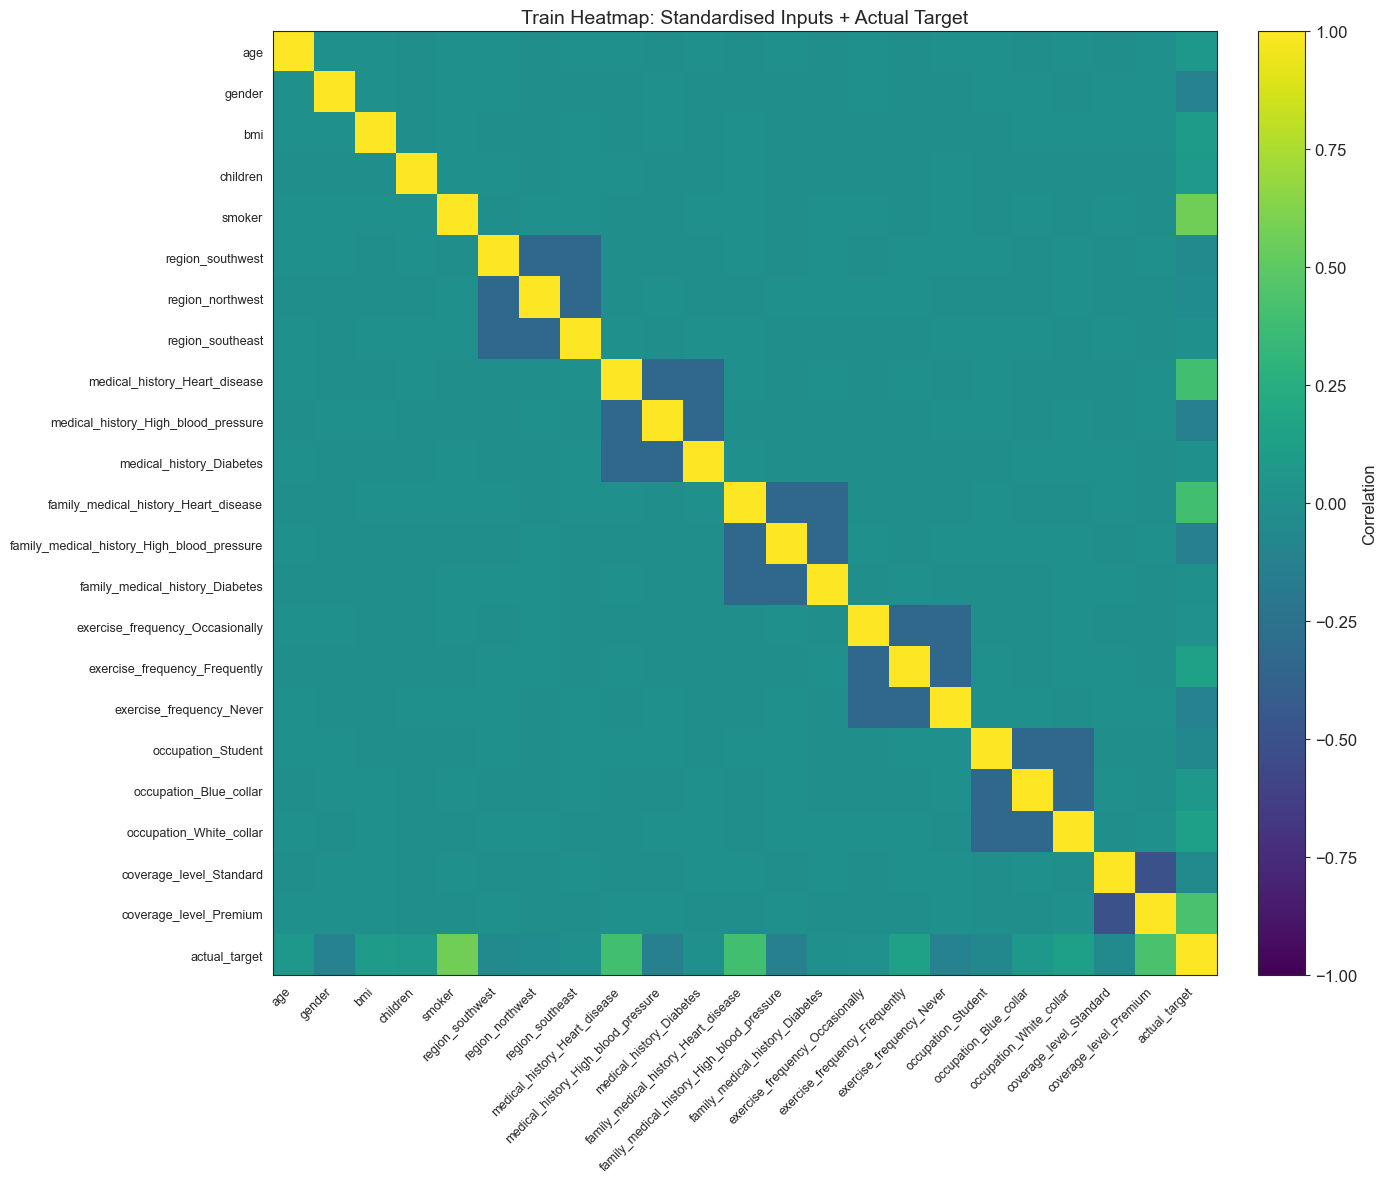

Figure saved: fig_eda_heatmap_train_actual.png


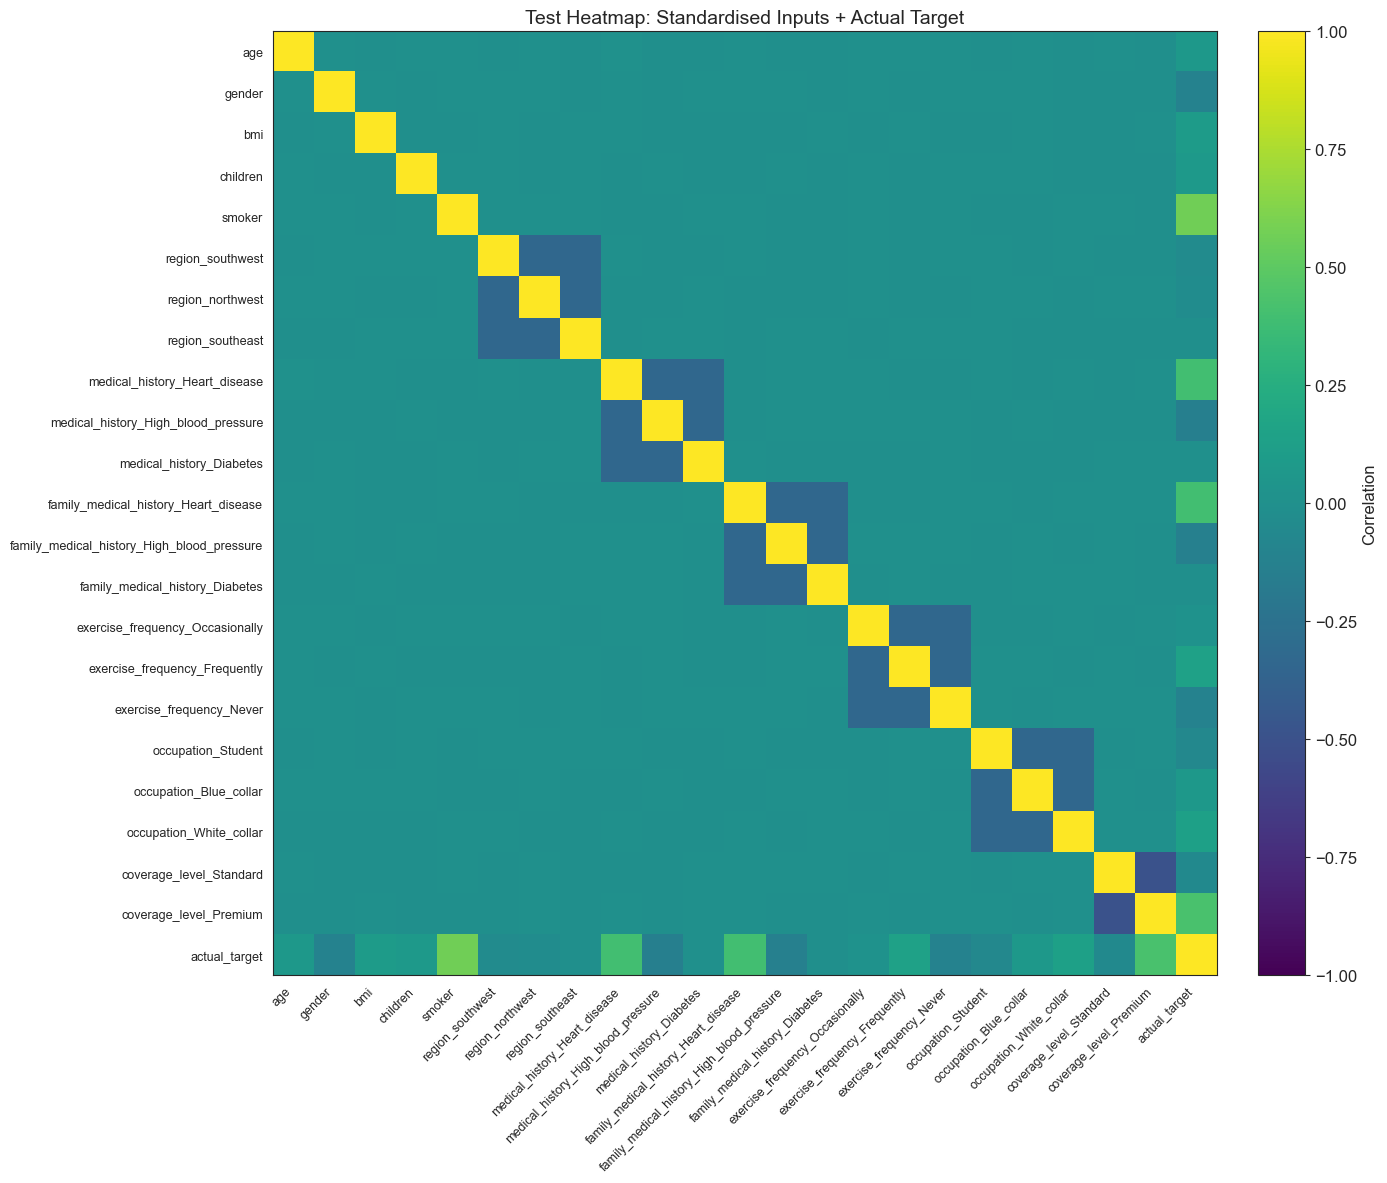

Figure saved: fig_eda_heatmap_test_actual.png

TARGET CORRELATIONS: TRAIN vs TEST
Feature                                        Train r   Test r     Diff
---------------------------------------------------------------------
age                                             0.0650   0.0666   0.0016
gender                                         -0.1126  -0.1125   0.0001
bmi                                             0.1058   0.1011   0.0047
children                                        0.0781   0.0741   0.0040
smoker                                          0.5665   0.5649   0.0016
region_southwest                               -0.0394  -0.0373   0.0021
region_northwest                               -0.0270  -0.0286   0.0016
region_southeast                                0.0016  -0.0012   0.0028
medical_history_Heart_disease                   0.3929   0.3931   0.0002
medical_history_High_blood_pressure            -0.1321  -0.1333   0.0012
medical_history_Diabetes                     

In [40]:
# --- Helper: build DataFrame of standardised inputs + target ---
def build_corr_df(X_std, target_values, target_label, features):
    df = pd.DataFrame(X_std, columns=features)
    df[target_label] = target_values
    return df


# --- Helper: plot correlation heatmap (viridis, fixed [-1, 1] range) ---
def plot_corr_heatmap(corr_matrix, title, save_name):
    fig, ax = plt.subplots(figsize=(14, 12))
    im = ax.imshow(corr_matrix.values, cmap='viridis', vmin=-1, vmax=1, aspect='auto')

    n = len(corr_matrix)
    ax.set_xticks(range(n))
    ax.set_yticks(range(n))
    ax.set_xticklabels(corr_matrix.columns, rotation=45, ha='right', fontsize=9)
    ax.set_yticklabels(corr_matrix.index, fontsize=9)

    cbar = plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    cbar.set_label('Correlation')

    ax.set_title(title, fontsize=14)
    plt.tight_layout()
    plt.savefig(FIG_DIR + save_name, dpi=300, bbox_inches='tight')
    plt.show()
    print(f'Figure saved: {save_name}')


# --- Heatmap 1: Training set, actual charges ---
df_train_corr = build_corr_df(X_train_std, y_train_vals, 'actual_target', FEATURES)
corr_train = df_train_corr.corr()
plot_corr_heatmap(
    corr_train,
    title='Train Heatmap: Standardised Inputs + Actual Target',
    save_name='fig_eda_heatmap_train_actual.png'
)

# --- Heatmap 2: Test set, actual charges ---
df_test_corr = build_corr_df(X_test_std, y_test_vals, 'actual_target', FEATURES)
corr_test = df_test_corr.corr()
plot_corr_heatmap(
    corr_test,
    title='Test Heatmap: Standardised Inputs + Actual Target',
    save_name='fig_eda_heatmap_test_actual.png'
)

# --- Target correlation comparison across splits ---
print('\n' + '=' * 60)
print('TARGET CORRELATIONS: TRAIN vs TEST')
print('=' * 60)
print(f'{"Feature":<45} {"Train r":>8} {"Test r":>8} {"Diff":>8}')
print('-' * 69)
for feat in FEATURES:
    r_train = corr_train.loc['actual_target', feat]
    r_test  = corr_test.loc['actual_target', feat]
    diff = abs(r_train - r_test)
    print(f'{feat:<45} {r_train:>8.4f} {r_test:>8.4f} {diff:>8.4f}')

## 13. Summary of Key EDA Findings

| Finding | Detail |
|---|---|
| **Sample size** | n = 1,000,000 observations |
| **Missing values** | medical_history (25.08%), family_medical_history (25.04%) -- treated as reference category |
| **Response (charges)** | Mean R16,735, SD R4,416, mild positive skewness (0.13), no log transform needed |
| **Strongest predictor** | Smoker status (r = 0.567 with charges, mean difference ~R5,000) |
| **Coverage level** | Clear tier: Basic R14,394 < Standard R16,413 < Premium R19,403 |
| **Medical history** | Heart disease associated with highest mean charge (R19,739) |
| **Numeric correlations** | Age, BMI, children are mutually uncorrelated and weakly correlated with charges |
| **Categorical balance** | All categories near-uniformly distributed (benchmark design property) |
| **Model-ready data** | 22 encoded predictors + 1 response, no missing values |
| **Split** | Train 524,288 / Validation 237,856 / Test 237,856 |
| **PCA (2 components)** | PC1 and PC2 explain a modest proportion of total variance; dominant loadings align with smoker, coverage and medical history features |
| **Heatmap consistency** | Train and test target-correlation vectors are near-identical, confirming partition integrity |

### Figures Produced (23 total)

| # | Filename | Description |
|---|---|---|
| 1 | `fig_missing_values.png` | Missing-value percentages per variable |
| 2 | `fig_numeric_distributions.png` | Histograms with mean/median for age, bmi, children, charges |
| 3 | `fig_numeric_boxplots.png` | Boxplots for all numeric variables |
| 4 | `fig_categorical_frequencies.png` | Bar charts for all 8 categorical predictors |
| 5 | `fig_charges_distribution.png` | Histogram + KDE + percentile markers for charges |
| 6 | `fig_charges_qqplot.png` | Normal QQ plot for charges |
| 7 | `fig_charges_by_all_categoricals.png` | Boxplots of charges by all 8 categorical predictors |
| 8 | `fig_charges_violin_plots.png` | Violin plots for the 4 most influential predictors |
| 9 | `fig_interaction_smoker_coverage.png` | Smoker x coverage level interaction |
| 10 | `fig_interaction_smoker_medical.png` | Smoker x medical history interaction |
| 11 | `fig_interaction_coverage_gender.png` | Coverage level x gender interaction |
| 12 | `fig_correlation_heatmap.png` | Pearson correlation heatmap (numeric variables) |
| 13 | `fig_scatter_numeric_vs_charges.png` | Scatter plots: age, bmi, children vs charges |
| 14 | `fig_encoded_correlations.png` | Bar chart: all 22 encoded predictor correlations with charges |
| 15 | `fig_full_encoded_correlation_heatmap.png` | Full 22x22 encoded predictor correlation matrix |
| 16 | `fig_split_charges_kde.png` | Overlaid KDE of charges across train/validation/test |
| 17 | `fig_split_numeric_kde.png` | Overlaid KDE of numeric predictors across splits |
| 18 | `fig_split_dummy_proportions.png` | Dummy-variable proportions across splits |
| 19 | `fig_eda_pca_train_actual.png` | PCA scatter: training inputs coloured by actual charges |
| 20 | `fig_eda_pca_test_actual.png` | PCA scatter: test inputs coloured by actual charges |
| 21 | `fig_eda_pca_loadings.png` | Horizontal bar charts of PC1 and PC2 loading vectors |
| 22 | `fig_eda_heatmap_train_actual.png` | Correlation heatmap: standardised train inputs + actual target |
| 23 | `fig_eda_heatmap_test_actual.png` | Correlation heatmap: standardised test inputs + actual target |

### Files Saved
- `eda_pca_loadings.csv` -- full PCA loading vectors for all 22 features